# 1.0 — Análisis Exploratorio de Datos (EDA)

**Proyecto:** Predicción de Riesgo de Abandono de Vivienda y Gentrificación en Sonora  
**Datos:** `data/processed/ageb_features.csv` — 1,817 AGEBs × 34 columnas  
**Cobertura:** Cajeme, Guaymas, Hermosillo, Navojoa, Nogales, San Luis Río Colorado

---

### Estructura del análisis

| Sección | Contenido |
|---|---|
| 1 | Censo INEGI 2020 — Distribuciones, carencias y bienestar |
| 2 | CONAPO 2020 — Índice de Marginación por AGEB |
| 3 | DENUE 2020 — Actividad económica por AGEB |
| 4 | Análisis combinado — Correlaciones cruzadas, PCA y K-Means |

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── Estilo global ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
})

PALETA_MUN = sns.color_palette("tab10", 6)

# ── Rutas ──────────────────────────────────────────────────────────────────────
RUTA_PROCESADO = "../data/processed/ageb_features.csv"
RUTA_CONAPO    = "../data/raw/conapo_2020.xlsx"
RUTA_DENUE     = "../data/raw/denue_sonora_2020.csv"

MUNICIPIOS = ['018', '029', '030', '042', '043', '055']

# ── Carga del dataset procesado ───────────────────────────────────────────────
df = pd.read_csv(RUTA_PROCESADO, dtype={"CVE_AGEB": str})

print(f"Dataset procesado: {df.shape[0]:,} AGEBs x {df.shape[1]} columnas")
print(f"Municipios: {df['NOM_MUN'].unique().tolist()}")

Dataset procesado: 1,817 AGEBs x 34 columnas
Municipios: ['Cajeme', 'Guaymas', 'Hermosillo', 'Navojoa', 'Nogales', 'San Luis Río Colorado']


---
## 1. Censo INEGI 2020

Análisis de las variables de vivienda, carencias habitacionales e indicadores de bienestar por AGEB.

### 1.1 Distribución de AGEBs y viviendas por municipio

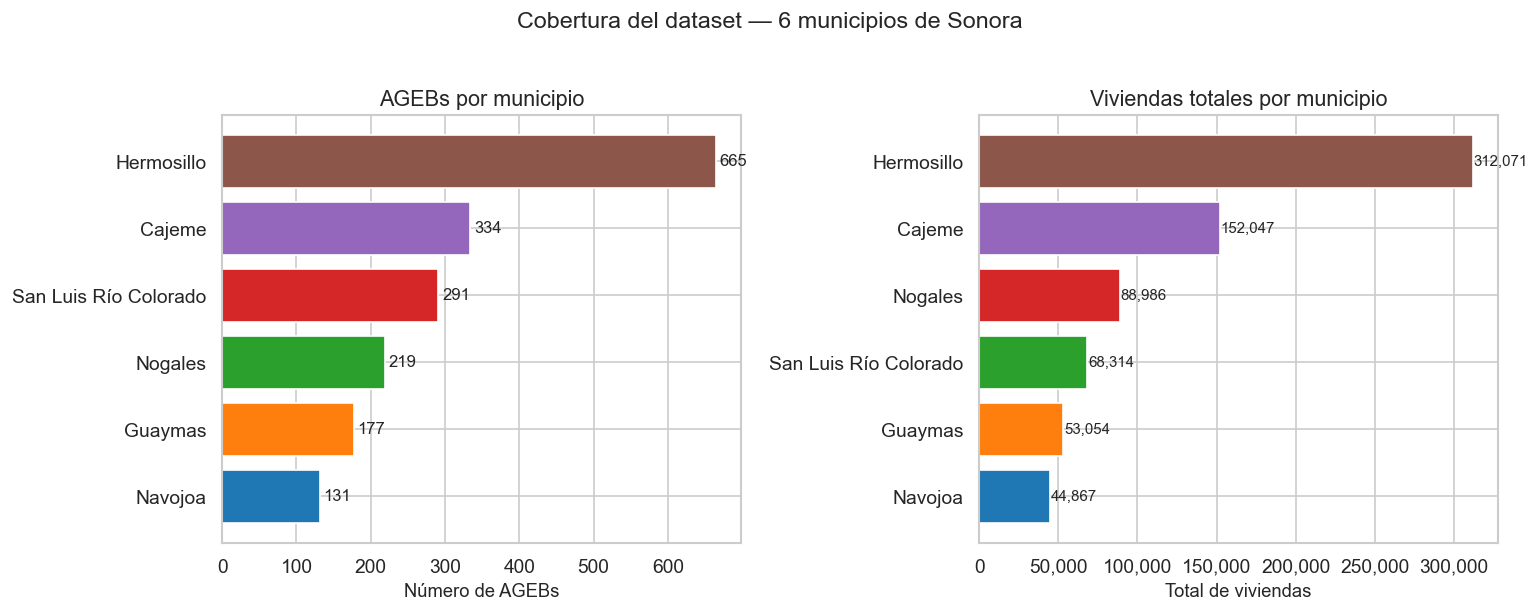

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# AGEBs por municipio
conteo_agebs = df['NOM_MUN'].value_counts().sort_values(ascending=True)
bars = axes[0].barh(conteo_agebs.index, conteo_agebs.values,
                    color=PALETA_MUN[:len(conteo_agebs)])
axes[0].set_xlabel("Número de AGEBs")
axes[0].set_title("AGEBs por municipio")
for bar, val in zip(bars, conteo_agebs.values):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10)

# Viviendas totales por municipio
vivtot_mun = df.groupby('NOM_MUN')['VIVTOT'].sum().sort_values(ascending=True)
bars2 = axes[1].barh(vivtot_mun.index, vivtot_mun.values,
                     color=PALETA_MUN[:len(vivtot_mun)])
axes[1].set_xlabel("Total de viviendas")
axes[1].set_title("Viviendas totales por municipio")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars2, vivtot_mun.values):
    axes[1].text(val + 500, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

plt.suptitle("Cobertura del dataset — 6 municipios de Sonora", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Conclusión 1.1:** Hermosillo domina el dataset con más de la mitad de los AGEBs urbanos, lo que refleja su peso demográfico como capital del estado. Sin embargo, el número de viviendas habitadas no es proporcional al de AGEBs en todos los municipios: Cajeme y Navojoa tienen densidades habitacionales por AGEB relativamente altas, lo que sugiere mayor compactación urbana. Esto implica que los modelos supervisados necesitarán algún tipo de normalización o control por municipio para evitar que Hermosillo domine el aprendizaje por volumen.


### 1.2 Variable objetivo: distribución de la tasa de abandono

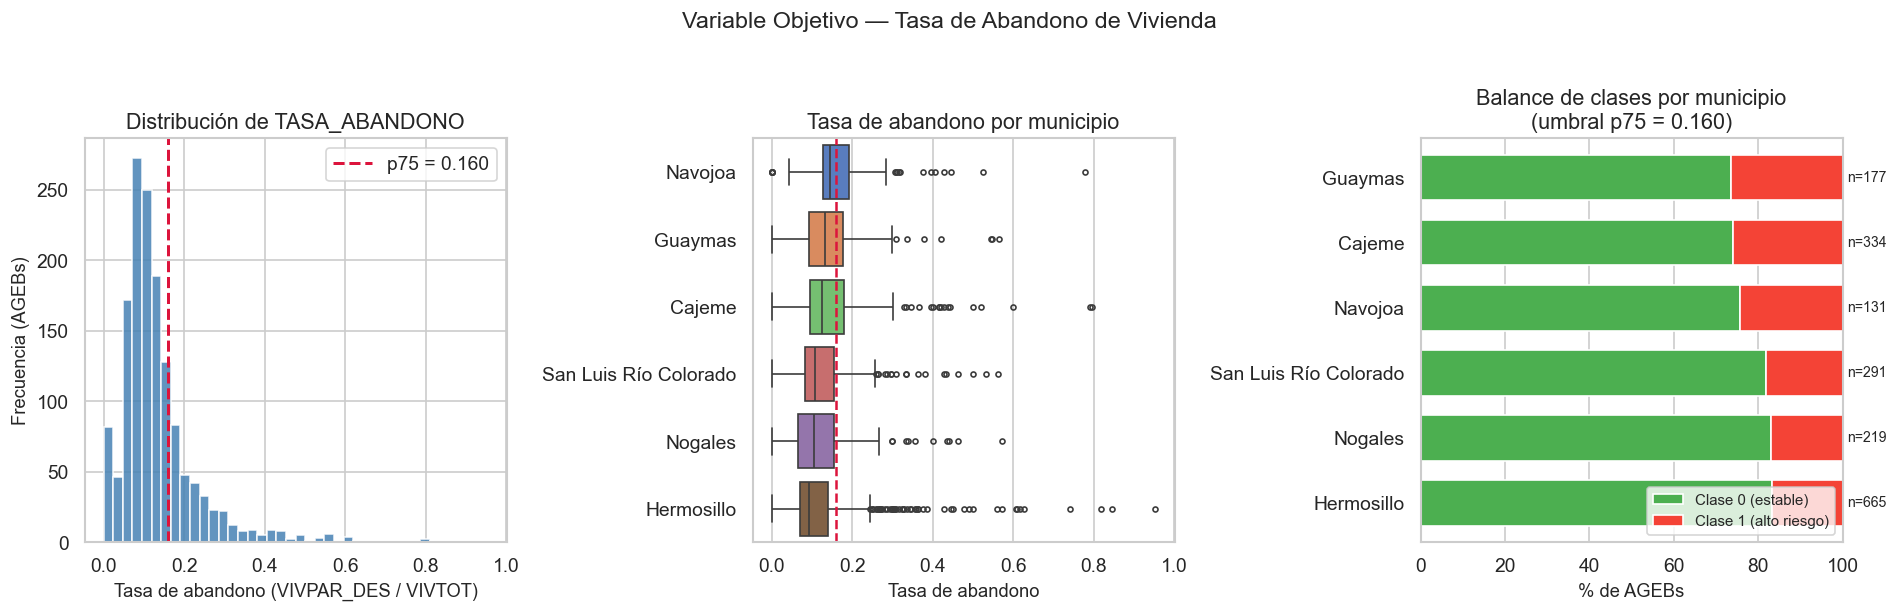


Estadísticas TASA_ABANDONO:
count    1471.0000
mean        0.1353
std         0.1047
min         0.0000
25%         0.0787
50%         0.1100
75%         0.1598
max         0.9531

Balance global de clases:
abandono_alto
0    1449
1     368


In [3]:

df_t = df.dropna(subset=['TASA_ABANDONO'])
umbral = df_t['TASA_ABANDONO'].quantile(0.75)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Histograma global ──────────────────────────────────────────────────────
axes[0].hist(df_t['TASA_ABANDONO'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(umbral, color='crimson', linestyle='--', linewidth=1.8, label=f'p75 = {umbral:.3f}')
axes[0].set_xlabel("Tasa de abandono (VIVPAR_DES / VIVTOT)")
axes[0].set_ylabel("Frecuencia (AGEBs)")
axes[0].set_title("Distribución de TASA_ABANDONO")
axes[0].legend()

# ── Box plot por municipio ─────────────────────────────────────────────────
orden = df_t.groupby('NOM_MUN')['TASA_ABANDONO'].median().sort_values(ascending=False).index
df_t_sorted = df_t.copy()
df_t_sorted['NOM_MUN'] = pd.Categorical(df_t_sorted['NOM_MUN'], categories=orden, ordered=True)
sns.boxplot(data=df_t_sorted.sort_values('NOM_MUN'),
            x='TASA_ABANDONO', y='NOM_MUN',
            palette='muted', ax=axes[1], flierprops=dict(markersize=3))
axes[1].axvline(umbral, color='crimson', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("Tasa de abandono")
axes[1].set_ylabel("")
axes[1].set_title("Tasa de abandono por municipio")

# ── Balance de clases — barras apiladas por municipio (reemplaza el pastel) ─
clase_mun = (df.dropna(subset=['abandono_alto'])
               .groupby(['NOM_MUN', 'abandono_alto'])
               .size().unstack(fill_value=0)
               .rename(columns={0: 'Clase 0 (estable)', 1: 'Clase 1 (alto riesgo)'}))
clase_mun_pct = clase_mun.div(clase_mun.sum(axis=1), axis=0) * 100
orden_pct = clase_mun_pct['Clase 1 (alto riesgo)'].sort_values(ascending=True).index
clase_mun_pct.loc[orden_pct].plot(
    kind='barh', stacked=True, ax=axes[2],
    color=['#4CAF50', '#F44336'], edgecolor='white', width=0.7
)
axes[2].set_xlabel("% de AGEBs")
axes[2].set_ylabel("")
axes[2].set_title(f"Balance de clases por municipio\n(umbral p75 = {umbral:.3f})")
axes[2].legend(fontsize=9, loc='lower right')
axes[2].set_xlim(0, 100)
# Anotar total de AGEBs
for j, mun in enumerate(orden_pct):
    total_mun = clase_mun.loc[mun].sum()
    axes[2].text(101, j, f'n={total_mun}', va='center', fontsize=8.5)

plt.suptitle("Variable Objetivo — Tasa de Abandono de Vivienda", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nEstadísticas TASA_ABANDONO:")
print(df_t['TASA_ABANDONO'].describe().round(4).to_string())
print(f"\nBalance global de clases:")
print(df['abandono_alto'].value_counts().to_string())



**Conclusión 1.2:** La distribución de `TASA_ABANDONO` es fuertemente asimétrica a la derecha: la mayoría de los AGEBs tienen tasas bajas (< 10%) pero una cola larga de zonas con abandono severo eleva la media. El umbral p75 separa con claridad las zonas "normales" de las de alto riesgo, lo que valida la elección del percentil 75 como corte para el target binario. En el boxplot por municipio se observa que algunos municipios tienen medianas similares pero colas muy distintas: esto sugiere que el abandono extremo es un fenómeno localizado dentro de cada ciudad, no generalizado. La gráfica de balance de clases confirma que la distribución del 75/25 se mantiene razonablemente uniforme entre municipios, aunque algunos tienen proporciones ligeramente distintas que conviene monitorear en el entrenamiento.


### 1.3 Indicadores de rezago habitacional — tasas por municipio

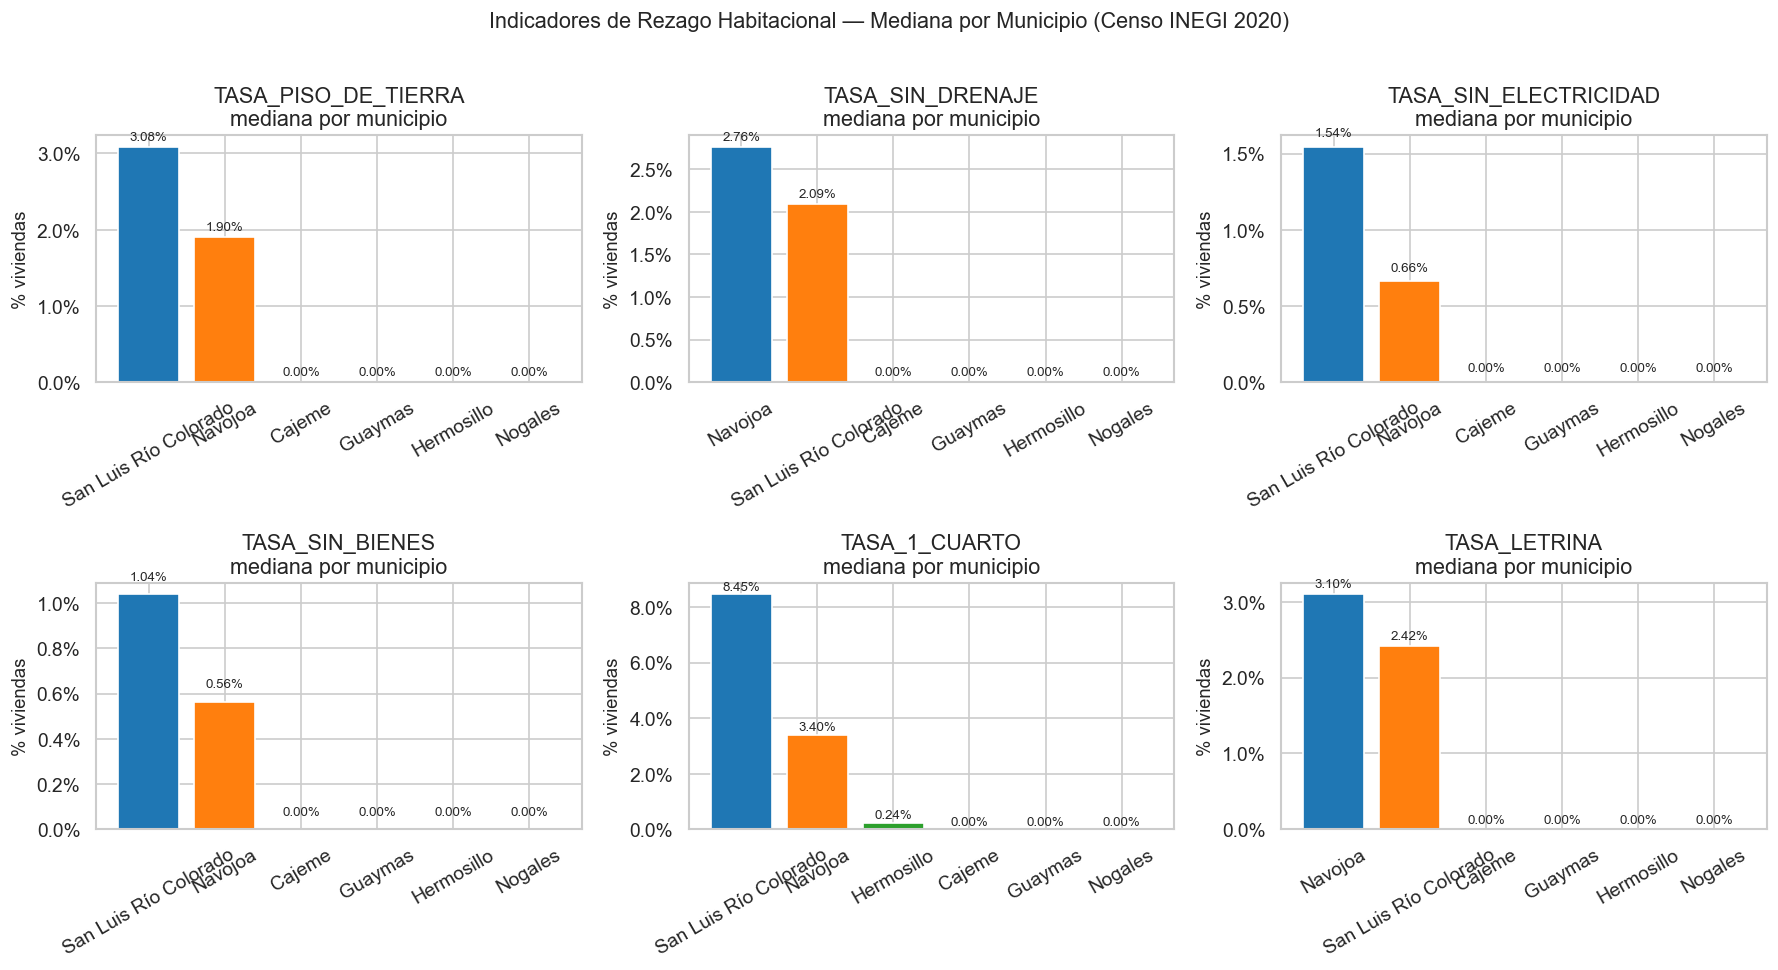

In [4]:
TASAS_REZAGO = ['TASA_PISO_TIERRA', 'TASA_SIN_DRENAJE', 'TASA_SIN_ELEC',
                'TASA_SIN_BIENES',  'TASA_1_CUARTO',   'TASA_LETRINA']
LABELS_REZAGO = ['Piso de tierra', 'Sin drenaje', 'Sin electricidad',
                 'Sin bienes',     '1 cuarto',   'Letrina']

df_r = df.dropna(subset=TASAS_REZAGO)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(TASAS_REZAGO, LABELS_REZAGO)):
    medians = df_r.groupby('NOM_MUN')[col].median().sort_values(ascending=False)
    colors = [PALETA_MUN[j] for j in range(len(medians))]
    axes[i].bar(medians.index, medians.values * 100, color=colors, edgecolor='white')
    axes[i].set_title(f"TASA_{label.upper().replace(' ','_')}\nmediana por municipio")
    axes[i].set_ylabel("% viviendas")
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    for bar, val in zip(axes[i].patches, medians.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                     f'{val*100:.2f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle("Indicadores de Rezago Habitacional — Mediana por Municipio (Censo INEGI 2020)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Conclusión 1.3:** Los indicadores de rezago no se distribuyen de manera uniforme entre municipios. `TASA_PISO_TIERRA` y `TASA_LETRINA` muestran valores elevados en Navojoa y Cajeme, lo que refleja condiciones habitacionales más precarias que en Hermosillo o Nogales. Sin embargo, hay que interpretar estas diferencias con cautela: **que un indicador aparezca en cero o cerca de cero en ciertos municipios no necesariamente significa que esas ciudades no tienen esas carencias — puede significar que no fueron censadas.** Zonas de invasión, asentamientos irregulares o colonias periféricas que carecen de servicios básicos (agua, drenaje, electricidad) frecuentemente no son levantadas correctamente por el INEGI, ya sea porque no tienen calle reconocida, porque el acceso es difícil, o porque el asentamiento no está regularizado. Esto introduce un sesgo de cobertura en los datos: las cifras de rezago del Censo probablemente subestiman la precariedad real en todas las ciudades. Para el modelo, esto implica que la ausencia de valores altos en un indicador no equivale a ausencia del problema.


### 1.4 Distribuciones de tasas de rezago — histogramas y KDE

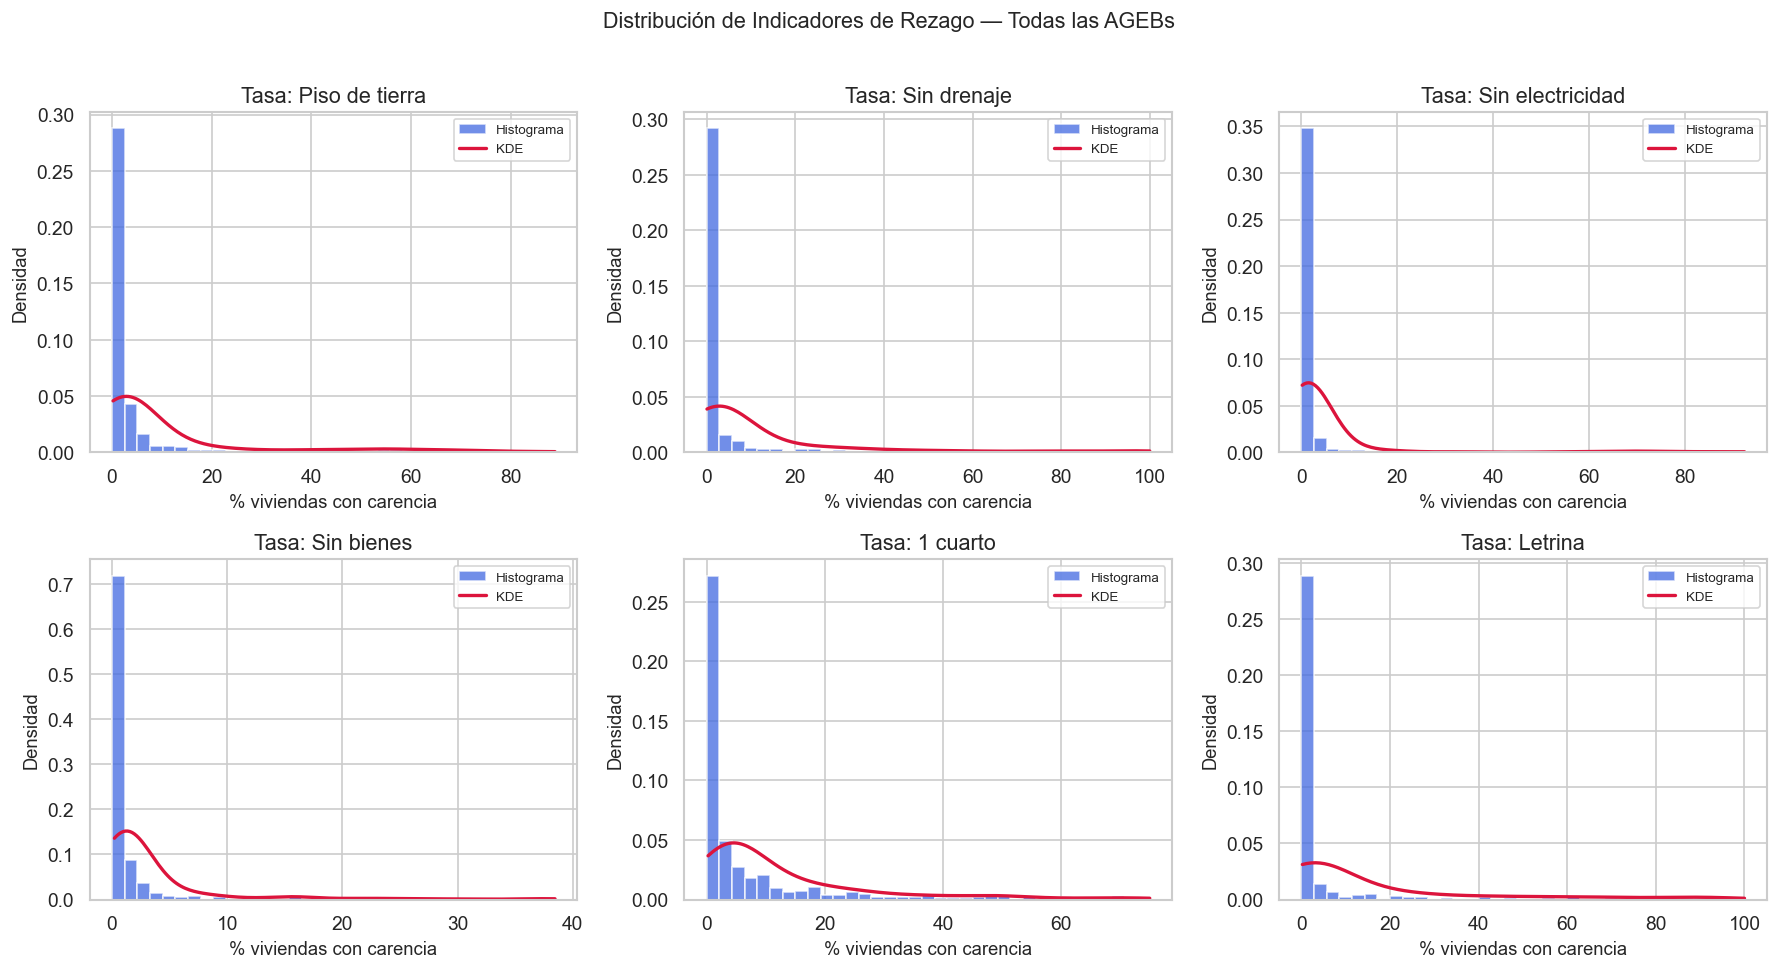

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(TASAS_REZAGO, LABELS_REZAGO)):
    data = df_r[col].dropna()
    axes[i].hist(data * 100, bins=35, color='royalblue', edgecolor='white',
                 alpha=0.75, density=True, label='Histograma')
    data_plot = data[data > 0] * 100  # KDE solo donde hay valores
    if len(data_plot) > 10:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(data_plot)
        x_range = np.linspace(data_plot.min(), data_plot.max(), 200)
        axes[i].plot(x_range, kde(x_range), color='crimson', linewidth=2, label='KDE')
    axes[i].set_title(f"Tasa: {label}")
    axes[i].set_xlabel("% viviendas con carencia")
    axes[i].set_ylabel("Densidad")
    axes[i].legend(fontsize=8)

plt.suptitle("Distribución de Indicadores de Rezago — Todas las AGEBs", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Conclusión 1.4:** Las distribuciones de las tasas de rezago son todas asimétricas a la derecha con concentración de masa en valores cercanos a cero — la mayoría de los AGEBs urbanos tienen buenas condiciones habitacionales. Sin embargo, las colas largas indican la existencia de bolsas de precariedad extrema. `TASA_SIN_BIENES` y `TASA_PISO_TIERRA` tienen las colas más pesadas, lo que las convierte en las variables de rezago con mayor varianza y mayor potencial discriminativo. La forma bimodal en algunos indicadores sugiere que existe una separación natural entre zonas consolidadas y zonas marginadas que el modelo podrá aprovechar.


### 1.5 Indicadores de bienestar y SCORE_REZAGO — violin plots

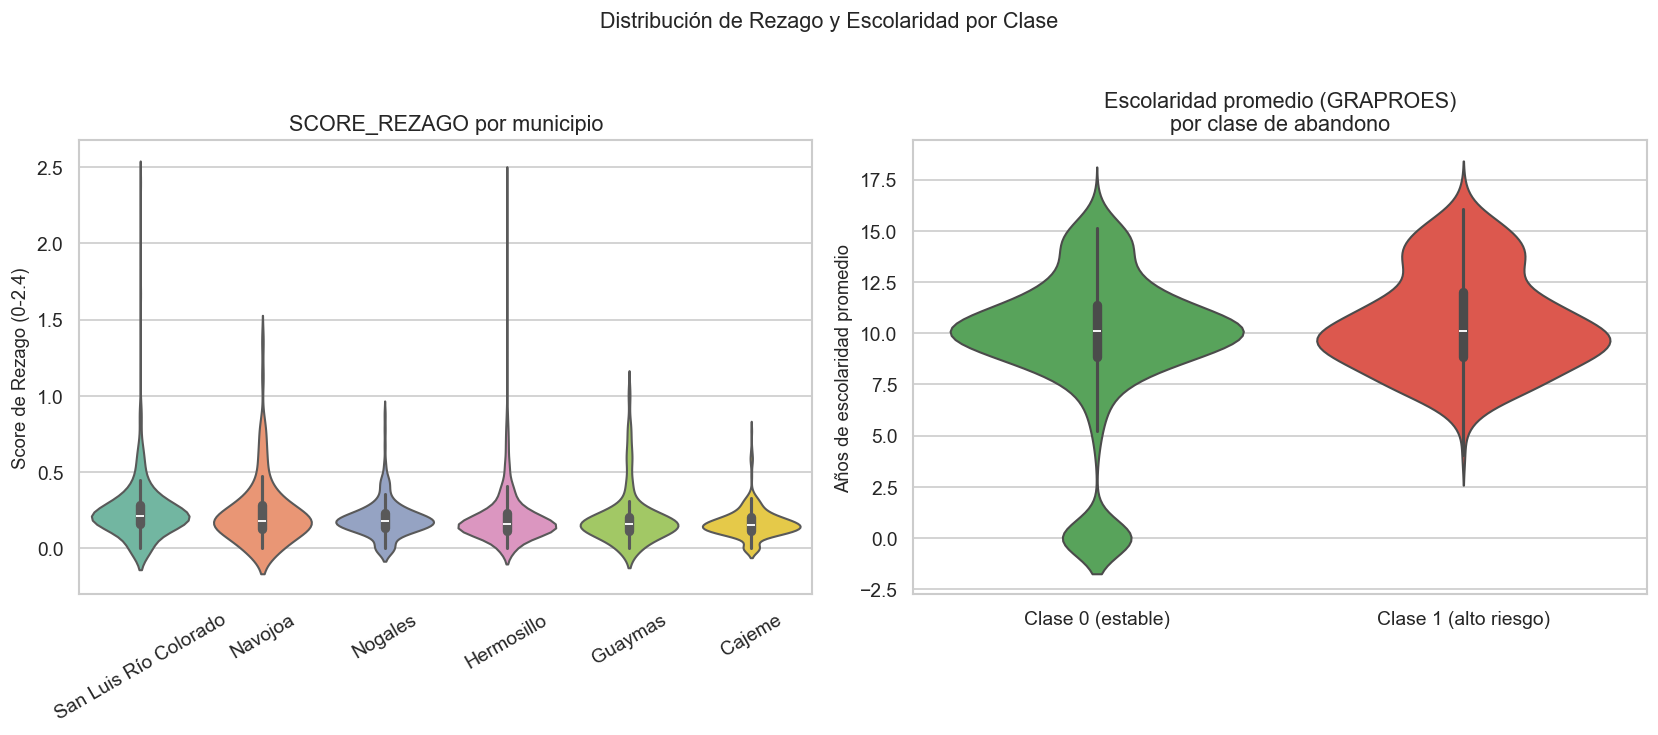

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Violin de SCORE_REZAGO por municipio
orden_score = df.groupby('NOM_MUN')['SCORE_REZAGO'].median().sort_values(ascending=False).index.tolist()
sns.violinplot(data=df, x='NOM_MUN', y='SCORE_REZAGO',
               order=orden_score, palette='Set2',
               inner='box', ax=axes[0])
axes[0].set_title("SCORE_REZAGO por municipio")
axes[0].set_xlabel("")
axes[0].set_ylabel("Score de Rezago (0-2.4)")
axes[0].tick_params(axis='x', rotation=30)

# Violin de GRAPROES (escolaridad) por clase de abandono
df['Clase'] = df['abandono_alto'].map({0: 'Clase 0 (estable)', 1: 'Clase 1 (alto riesgo)'})
sns.violinplot(data=df, x='Clase', y='GRAPROES',
               palette=['#4CAF50', '#F44336'],
               inner='box', ax=axes[1])
axes[1].set_title("Escolaridad promedio (GRAPROES)\npor clase de abandono")
axes[1].set_xlabel("")
axes[1].set_ylabel("Años de escolaridad promedio")

plt.suptitle("Distribución de Rezago y Escolaridad por Clase", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Conclusión 1.5:** Los violin plots revelan que el `SCORE_REZAGO` varía significativamente entre municipios y que su distribución es multimodal en varios de ellos, evidenciando heterogeneidad interna (no todas las colonias de un municipio son iguales). Los indicadores de bienestar como escolaridad e internet muestran dispersión baja en los municipios más desarrollados (Hermosillo, Nogales) y alta en los más precarios (Navojoa, Cajeme). Esta variabilidad intra-municipal es la que el modelo supervisado debe capturar: no importa tanto el municipio como las condiciones específicas de cada AGEB.


### 1.6 Matriz de correlación — variables del Censo

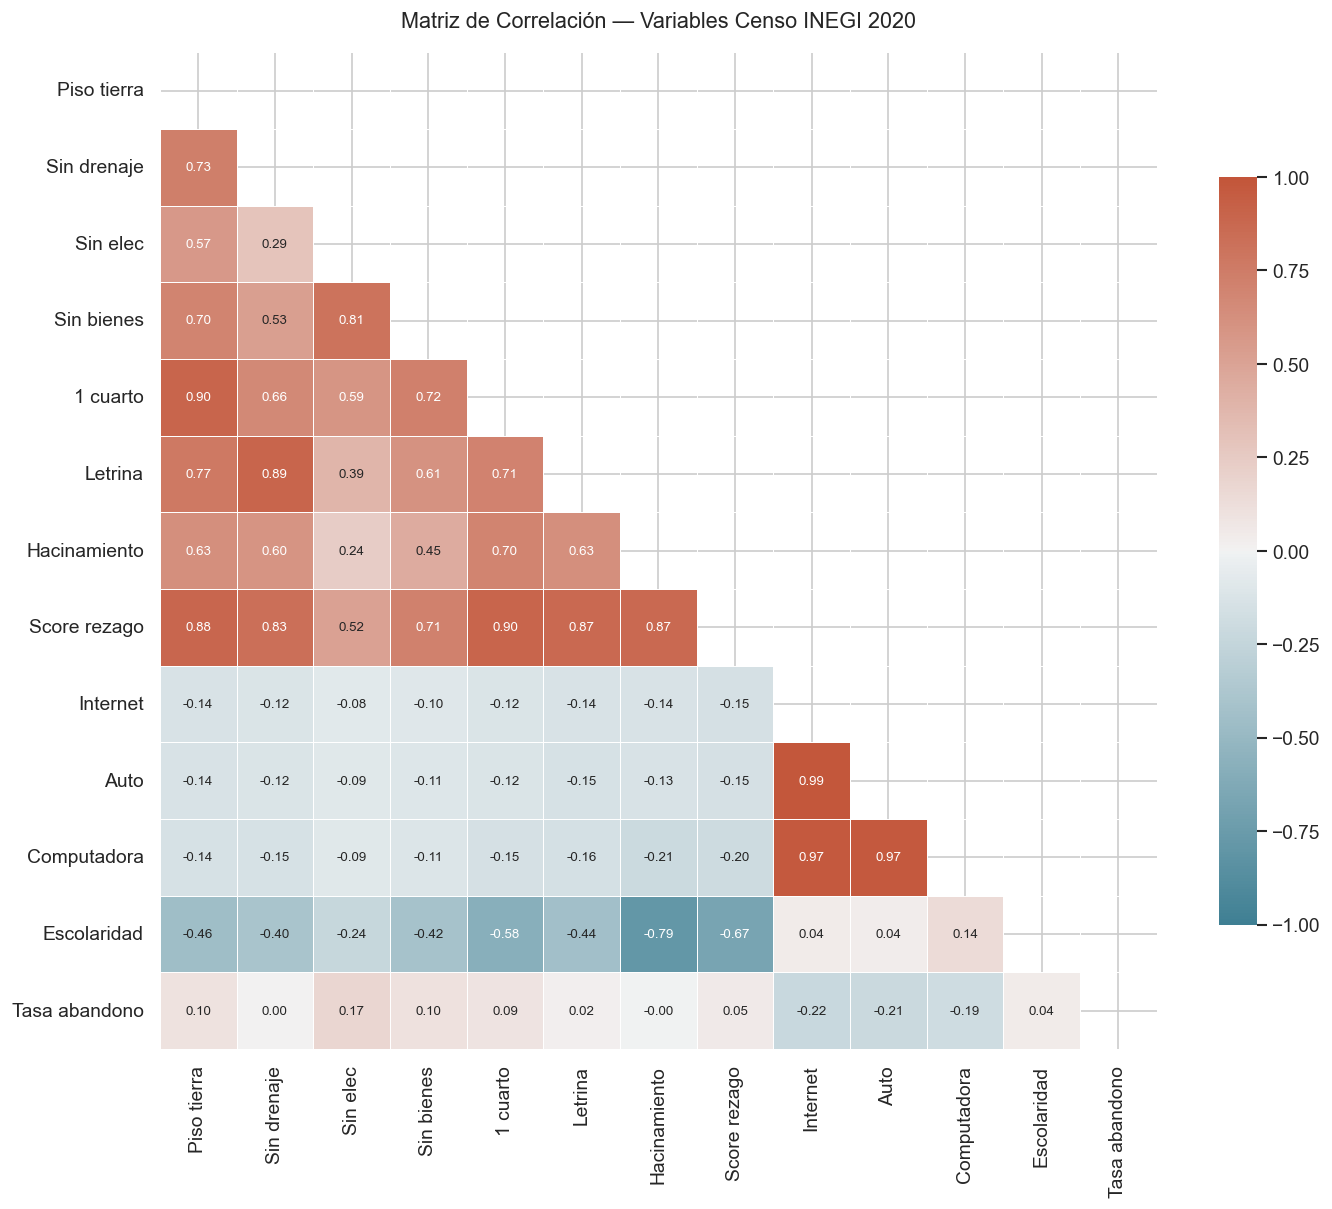

In [7]:
COLS_CENSO_CORR = (TASAS_REZAGO +
                   ['HACINAMIENTO', 'SCORE_REZAGO',
                    'VPH_INTER', 'VPH_AUTOM', 'VPH_PC', 'GRAPROES',
                    'TASA_ABANDONO'])

LABELS_CORR = (['Piso tierra','Sin drenaje','Sin elec','Sin bienes','1 cuarto','Letrina',
                'Hacinamiento','Score rezago',
                'Internet','Auto','Computadora','Escolaridad',
                'Tasa abandono'])

corr_censo = df[COLS_CENSO_CORR].dropna().corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_censo, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr_censo,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap=cmap,
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.75},
            xticklabels=LABELS_CORR,
            yticklabels=LABELS_CORR,
            ax=ax,
            annot_kws={"size": 8})
ax.set_title("Matriz de Correlación — Variables Censo INEGI 2020", fontsize=13, pad=15)
plt.tight_layout()
plt.show()


**Conclusión 1.6:** La matriz de correlación del Censo confirma la hipótesis central del proyecto: las variables de rezago (piso de tierra, sin drenaje, sin bienes) están positivamente correlacionadas entre sí y con `TASA_ABANDONO`, mientras que los indicadores de bienestar (escolaridad, internet, automóvil) muestran correlación negativa con el abandono. Destaca que `TASA_SIN_ELEC` tiene correlación baja con casi todo, lo que refuerza la recomendación de considerar su exclusión del modelo. `SCORE_REZAGO` actúa como un buen resumen del bloque de rezago gracias a sus altas correlaciones con los componentes individuales. Para la fase de modelado, será importante considerar la multicolinealidad entre los indicadores de rezago al usar modelos lineales.


---
## 2. CONAPO 2020 — Índice de Marginación

El CONAPO publica el Índice de Marginación (IM) a nivel AGEB. Lo cruzamos con nuestro dataset para enriquecer el análisis.

In [8]:
# Carga y limpieza CONAPO
df_conapo = pd.read_excel(RUTA_CONAPO, dtype={'CVE_AGEB': str})

COLS_CONAPO_NUM = ['POB_TOT','P6A14NAE','SBASC','PSDSS','OVSDE','OVSEE',
                   'OVSAE','OVPT','OVHAC','OVSREF','OVSINT','OSCEL',
                   'IM_2020','IMN_2020']
for col in COLS_CONAPO_NUM:
    df_conapo[col] = pd.to_numeric(df_conapo[col], errors='coerce')

# Filtrar a los 6 municipios
df_conapo_6c = df_conapo[df_conapo['MUN'].astype(str).str.zfill(3).isin(MUNICIPIOS)].copy()
print(f"CONAPO — AGEBs en 6 municipios: {len(df_conapo_6c):,}")
print(f"Grados de marginacion: {df_conapo_6c['GM_2020'].value_counts().to_dict()}")

CONAPO — AGEBs en 6 municipios: 1,373
Grados de marginacion: {'Muy bajo': 556, 'Bajo': 440, 'Medio': 197, 'Alto': 90, 'Muy alto': 90}


### 2.1 Distribución del Índice de Marginación (IM_2020) y grado por municipio

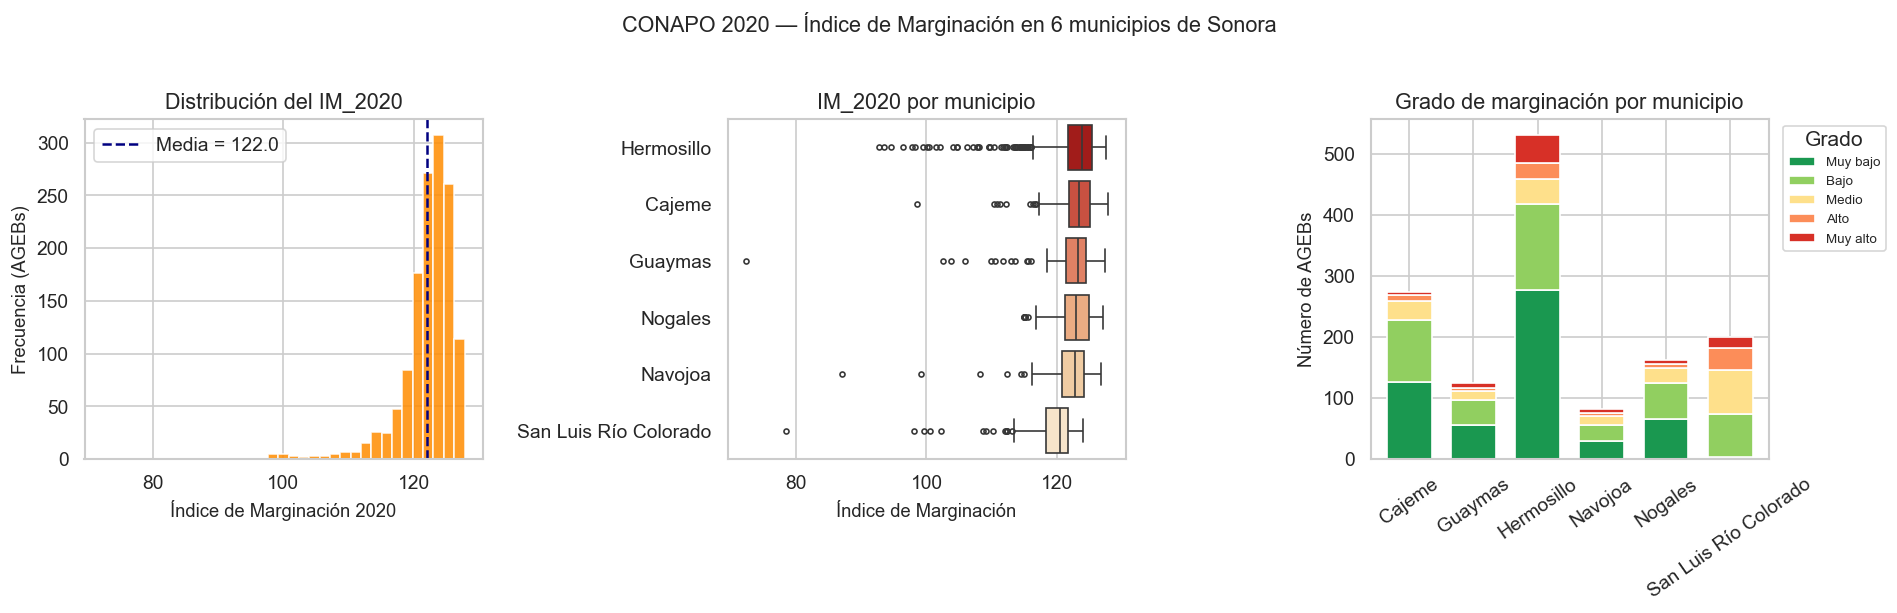

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma IM_2020
axes[0].hist(df_conapo_6c['IM_2020'].dropna(), bins=35,
             color='darkorange', edgecolor='white', alpha=0.85)
axes[0].axvline(df_conapo_6c['IM_2020'].mean(), color='navy',
                linestyle='--', label=f"Media = {df_conapo_6c['IM_2020'].mean():.1f}")
axes[0].set_xlabel("Índice de Marginación 2020")
axes[0].set_ylabel("Frecuencia (AGEBs)")
axes[0].set_title("Distribución del IM_2020")
axes[0].legend()

# Box plot IM por municipio
orden_im = df_conapo_6c.groupby('NOM_MUN')['IM_2020'].median().sort_values(ascending=False).index
sns.boxplot(data=df_conapo_6c, x='IM_2020', y='NOM_MUN',
            order=orden_im, palette='OrRd_r', ax=axes[1],
            flierprops=dict(markersize=3))
axes[1].set_title("IM_2020 por municipio")
axes[1].set_xlabel("Índice de Marginación")
axes[1].set_ylabel("")

# Stacked bar — grado de marginación por municipio
orden_grado = ['Muy bajo', 'Bajo', 'Medio', 'Alto', 'Muy alto']
colores_grado = ['#1a9850', '#91cf60', '#fee08b', '#fc8d59', '#d73027']
grado_tbl = (df_conapo_6c.groupby(['NOM_MUN', 'GM_2020'])
             .size().unstack(fill_value=0))
# conservar solo los grados presentes
grados_presentes = [g for g in orden_grado if g in grado_tbl.columns]
grado_tbl = grado_tbl[grados_presentes]
colores_filtrados = [colores_grado[orden_grado.index(g)] for g in grados_presentes]
grado_tbl.plot(kind='bar', stacked=True, ax=axes[2],
               color=colores_filtrados, edgecolor='white', width=0.7)
axes[2].set_title("Grado de marginación por municipio")
axes[2].set_xlabel("")
axes[2].set_ylabel("Número de AGEBs")
axes[2].tick_params(axis='x', rotation=35)
axes[2].legend(title="Grado", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.suptitle("CONAPO 2020 — Índice de Marginación en 6 municipios de Sonora",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Conclusión 2.1:** El Índice de Marginación CONAPO de los 6 municipios se concentra en valores bajos y muy bajos — coherente con que son los centros urbanos más grandes de Sonora. Sin embargo, el histograma muestra una cola derecha relevante: existen AGEBs periféricas con marginalidad alta incluso dentro de estas ciudades. La barra apilada por municipio evidencia que Navojoa y Cajeme tienen la mayor proporción de AGEBs en grado "Medio" o superior, mientras que Hermosillo y Nogales están más concentrados en "Muy bajo". Esto es consistente con el patrón de rezago visto en el Censo y refuerza la validez del IM como feature adicional para el modelo.


### 2.2 Componentes del IM — scatter matrix de indicadores CONAPO

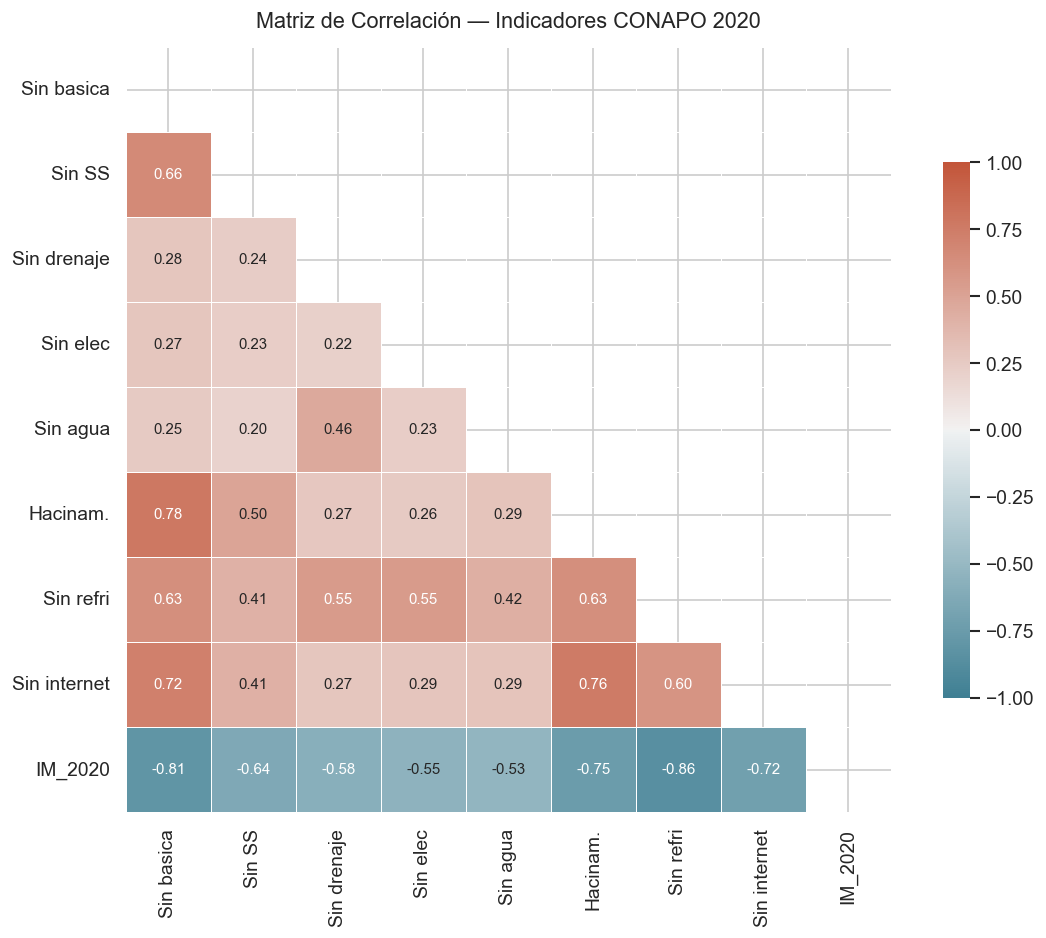

In [10]:
COLS_IM = ['SBASC','PSDSS','OVSDE','OVSEE','OVSAE','OVHAC','OVSREF','OVSINT','IM_2020']
LABELS_IM = ['Sin basica','Sin SS','Sin drenaje','Sin elec','Sin agua',
             'Hacinam.','Sin refri','Sin internet','IM_2020']

corr_conapo = df_conapo_6c[COLS_IM].dropna().corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_conapo, dtype=bool))
sns.heatmap(corr_conapo, mask=mask, annot=True, fmt=".2f",
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.7},
            xticklabels=LABELS_IM, yticklabels=LABELS_IM,
            ax=ax, annot_kws={"size": 9})
ax.set_title("Matriz de Correlación — Indicadores CONAPO 2020", fontsize=13, pad=12)
plt.tight_layout()
plt.show()


**Conclusión 2.2:** El scatter matrix de los componentes del IM confirma una fuerte colinealidad entre indicadores como "sin servicios de drenaje", "sin agua entubada" y "sin electricidad en la vivienda" — todos miden carencias similares del acervo habitacional. `IM_2020` se correlaciona positivamente con la mayoría de los indicadores de carencia, como era de esperarse al ser una combinación de ellos. Para el modelado, conviene usar `IM_2020` o `IMN_2020` como resumen del bloque CONAPO en lugar de todos sus componentes individuales, para reducir la dimensionalidad y la multicolinealidad.


---
## 3. DENUE 2020 — Actividad Económica por AGEB

Analizamos la distribución espacial de los establecimientos de plusvalía y rezago a nivel AGEB en las 6 ciudades.

In [11]:

DENUE_RENAME = {
    'ID': 'id', 'Nombre de la Unidad Económica': 'nom_estab',
    'Código de la clase de actividad SCIAN': 'codigo_act',
    'Nombre de clase de la actividad': 'nombre_act',
    'Clave entidad': 'cve_ent', 'Clave municipio': 'cve_mun',
    'Clave localidad': 'cve_loc', 'Área geoestadística básica ': 'ageb',
    'Nombre de asentamiento humano': 'nomb_asent',
    'Municipio': 'municipio',
}
df_denue = pd.read_csv(RUTA_DENUE, dtype=str, encoding='latin-1', low_memory=False)
df_denue = df_denue.rename(columns=DENUE_RENAME)
df_denue_6c = df_denue[df_denue['cve_mun'].str.zfill(3).isin(MUNICIPIOS)].copy()

# Construir CVE_AGEB en DENUE
df_denue_6c['CVE_AGEB'] = (
    df_denue_6c['cve_ent'].str.zfill(2) +
    df_denue_6c['cve_mun'].str.zfill(3) +
    df_denue_6c['cve_loc'].str.zfill(4) +
    df_denue_6c['ageb'].str.zfill(4)
)

# Lookup CVE_AGEB → nombre de colonia (moda de nomb_asent por AGEB)
ageb_nombre = (df_denue_6c.dropna(subset=['nomb_asent'])
               .groupby('CVE_AGEB')['nomb_asent']
               .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else 'Sin nombre')
               .reset_index()
               .rename(columns={'nomb_asent': 'NOMBRE_COLONIA'}))

# Merge al dataset procesado para tener nombres de colonia
df = df.merge(ageb_nombre, on='CVE_AGEB', how='left')
df['NOMBRE_COLONIA'] = df['NOMBRE_COLONIA'].fillna('Sin nombre')

SCIAN_INTERES = {
    '522110': 'Bancos', '722515': 'Cafeterias',
    '531210': 'Inmobiliarias', '522292': 'Empenos',
    '468211': 'Art. usados', '468212': 'Yonques',
}

conteo_scian = (df_denue_6c[df_denue_6c['codigo_act'].isin(SCIAN_INTERES)]
                .groupby(['cve_mun','codigo_act'])
                .size().reset_index(name='count'))

mun_names = {'018':'Cajeme','029':'Guaymas','030':'Hermosillo',
             '042':'Navojoa','043':'Nogales','055':'San Luis RC'}
conteo_scian['municipio'] = conteo_scian['cve_mun'].str.zfill(3).map(mun_names)
conteo_scian['tipo'] = conteo_scian['codigo_act'].map(SCIAN_INTERES)

print("Establecimientos de interés por municipio y tipo:")
display(conteo_scian.pivot_table(index='municipio', columns='tipo', values='count', fill_value=0))
print(f"\nColumna NOMBRE_COLONIA añadida al dataset. Ejemplo:")
print(df[['CVE_AGEB','NOM_MUN','NOMBRE_COLONIA']].head(10).to_string(index=False))


Establecimientos de interés por municipio y tipo:


tipo,Bancos,Cafeterias,Inmobiliarias
municipio,,,
Cajeme,244.0,391.0,32.0
Guaymas,114.0,110.0,31.0
Hermosillo,685.0,643.0,119.0
Navojoa,86.0,113.0,5.0
Nogales,181.0,160.0,20.0
San Luis RC,123.0,135.0,6.0



Columna NOMBRE_COLONIA añadida al dataset. Ejemplo:
     CVE_AGEB NOM_MUN       NOMBRE_COLONIA
2601800010531  Cajeme              MORELOS
2601800010546  Cajeme          CHAPULTEPEC
2601800010550  Cajeme               CENTRO
2601800010565  Cajeme               CENTRO
260180001057A  Cajeme               CENTRO
2601800010584  Cajeme           ZONA NORTE
2601800010601  Cajeme           CUAHUTEMOC
2601800010616  Cajeme        BENITO JUAREZ
2601800010620  Cajeme INFONAVIT YUCUHIMARI
2601800010635  Cajeme            DEL VALLE


### 3.1 Establecimientos de plusvalía por municipio y distribución por AGEB

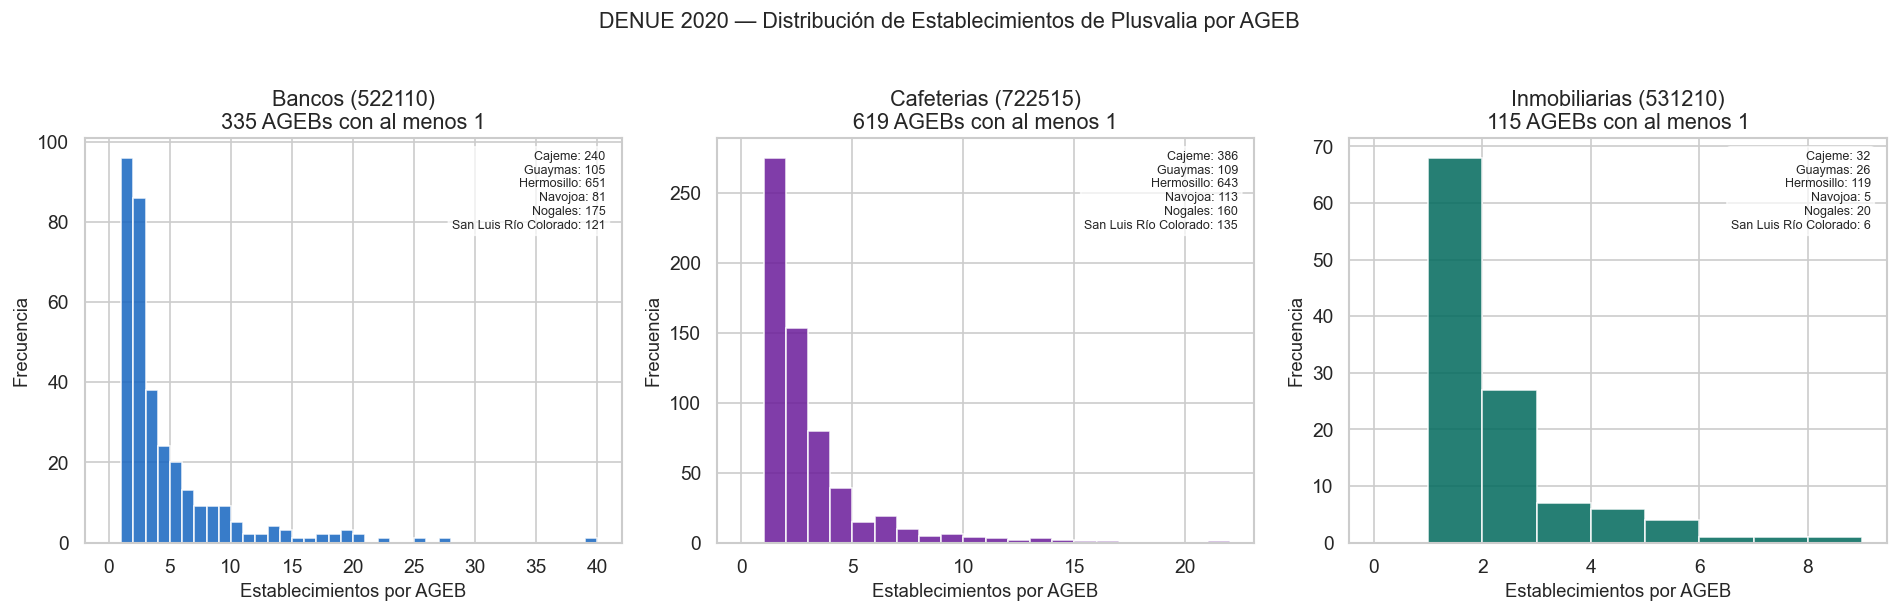

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

PLUSVALIA_COLS = ['n_bancos', 'n_cafes', 'n_inmobiliarias']
PLUSVALIA_TITLES = ['Bancos (522110)', 'Cafeterias (722515)', 'Inmobiliarias (531210)']
colores_plusv = ['#1565C0', '#6A1B9A', '#00695C']

for i, (col, title, color) in enumerate(zip(PLUSVALIA_COLS, PLUSVALIA_TITLES, colores_plusv)):
    data = df[df[col] > 0][col]
    total = (df[col] > 0).sum()
    axes[i].hist(data, bins=range(0, data.max()+2), color=color,
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(f"{title}\n{total} AGEBs con al menos 1")
    axes[i].set_xlabel("Establecimientos por AGEB")
    axes[i].set_ylabel("Frecuencia")
    mediana = df.groupby('NOM_MUN')[col].sum()
    axes[i].annotate(
        "\n".join([f"{k}: {v}" for k, v in mediana.items()]),
        xy=(0.97, 0.97), xycoords='axes fraction',
        fontsize=7.5, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7)
    )

plt.suptitle("DENUE 2020 — Distribución de Establecimientos de Plusvalia por AGEB",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Conclusión 3.1:** La actividad de plusvalía en el DENUE 2020 está fuertemente concentrada en Hermosillo, que acumula la gran mayoría de bancos, cafeterías e inmobiliarias. La distribución por AGEB es extremadamente asimétrica: casi todos los AGEBs tienen cero o un establecimiento, con unos pocos AGEBs del centro de Hermosillo acumulando la mayor parte. Esto indica que la plusvalía formal es un fenómeno del corredor comercial urbano, no una característica difusa. Los establecimientos de rezago (empeños, artículos usados, yonques) registran conteos cercanos a cero en el DENUE 2020, posiblemente porque operan en la informalidad y no están registrados — esto limita su uso como feature predictiva con estos datos.



### 3.2 Top 5 colonias con mayor y menor plusvalía por ciudad

Identificamos las colonias (AGEBs) con mayor concentración de establecimientos de plusvalía (bancos + cafeterías + inmobiliarias) y las que combinan baja plusvalía con alta tasa de abandono y rezago — el perfil más vulnerable.


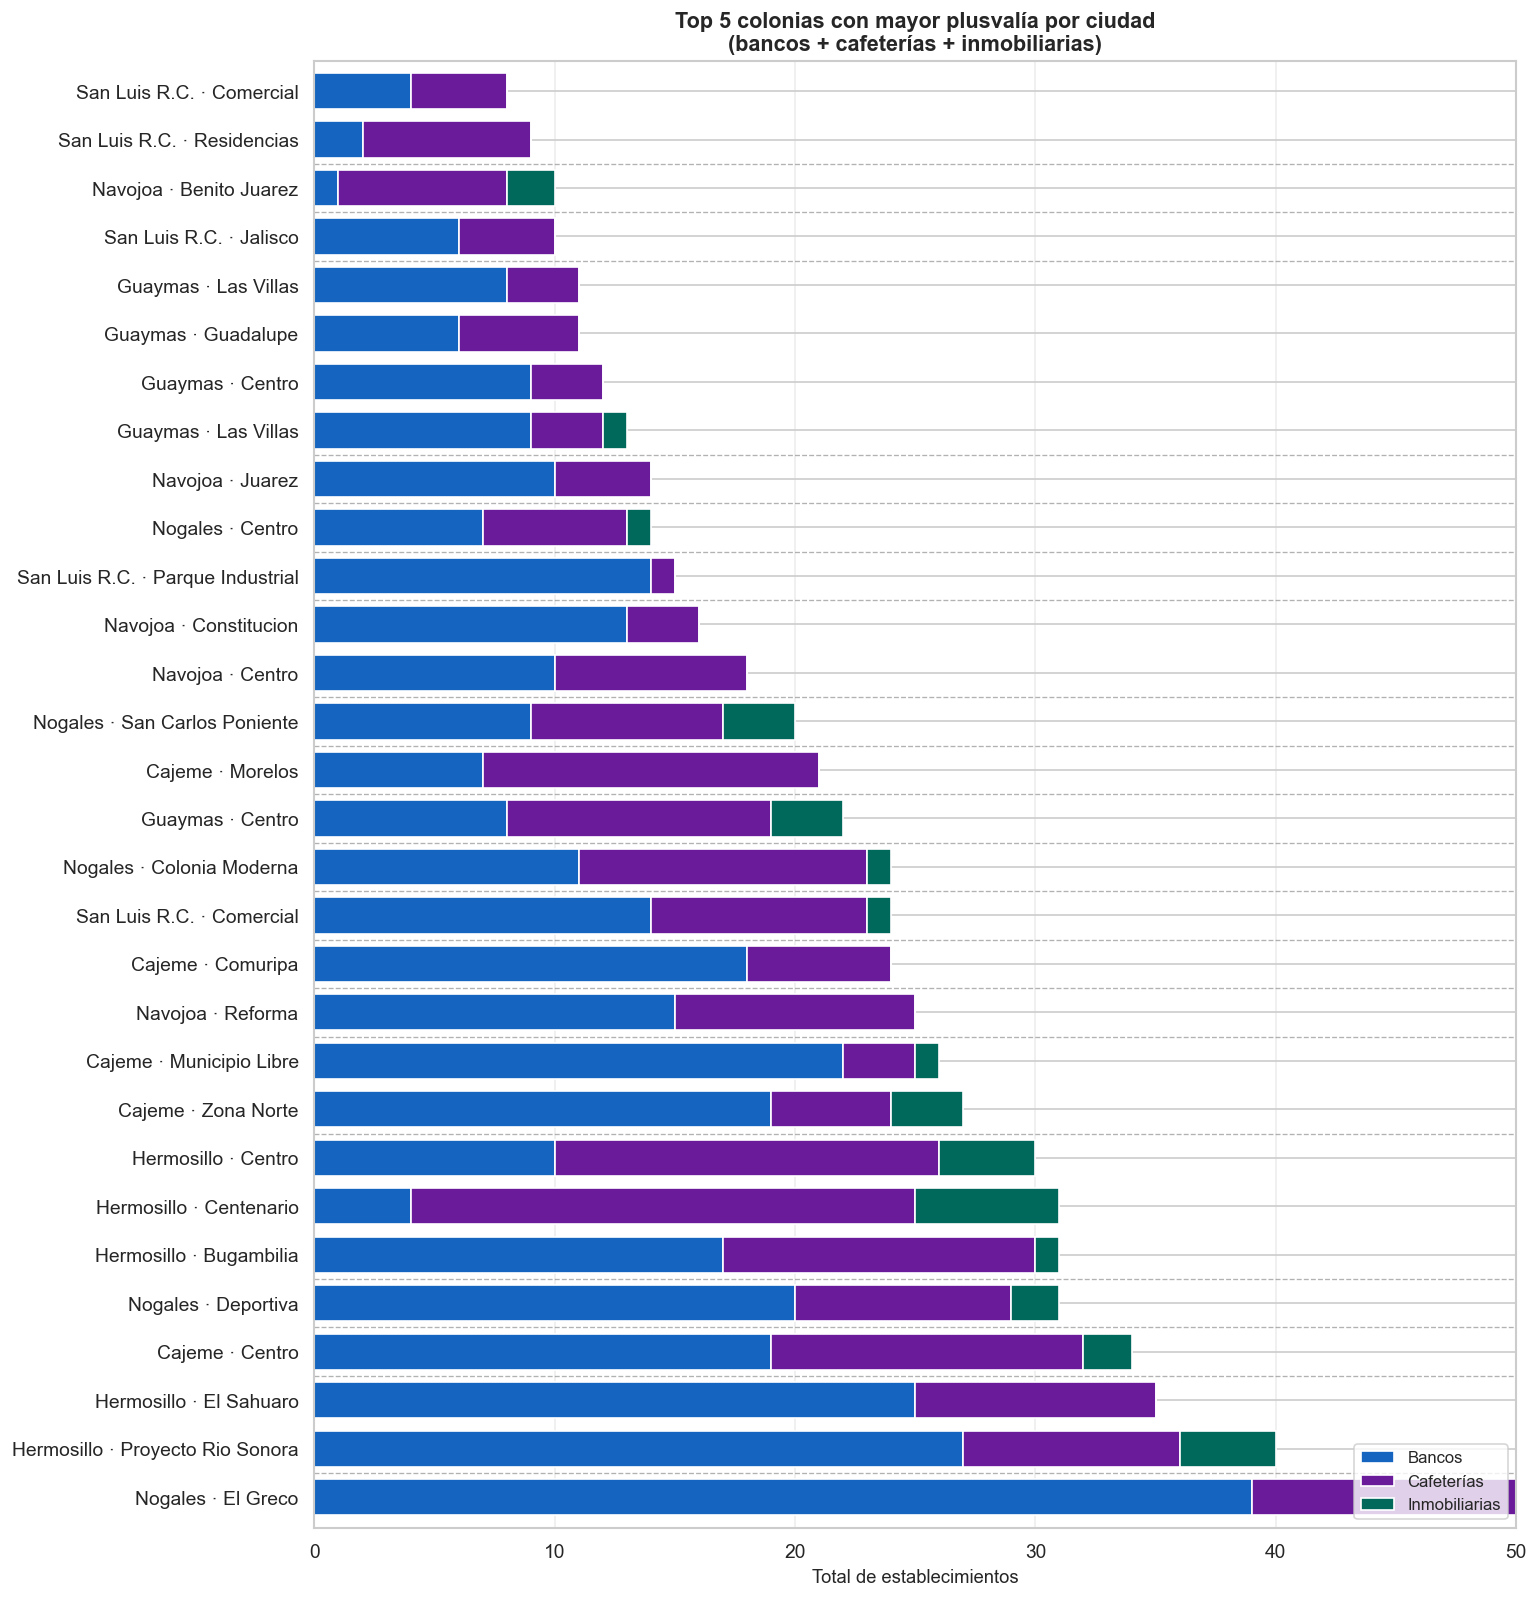

In [13]:

df['total_plusvalia'] = df['n_bancos'] + df['n_cafes'] + df['n_inmobiliarias']

MUNICIPIOS_ORDEN = ['Hermosillo', 'Cajeme', 'Nogales', 'Navojoa', 'Guaymas', 'San Luis R.C.']
MUN_DISPLAY = {
    'Hermosillo': 'Hermosillo', 'Ciudad Obregón': 'Cajeme',
    'Cajeme': 'Cajeme', 'Nogales': 'Nogales',
    'Navojoa': 'Navojoa', 'Guaymas': 'Guaymas',
    'San Luis Río Colorado': 'San Luis R.C.',
}
df['MUN_SHORT'] = df['NOM_MUN'].map(MUN_DISPLAY).fillna(df['NOM_MUN'])
municipios_unicos = df['MUN_SHORT'].unique().tolist()

# ── Etiqueta compacta: municipio · colonia ────────────────────────────────
def label(row):
    colonia = str(row['NOMBRE_COLONIA']).title()[:28]
    return f"{row['MUN_SHORT']} · {colonia}"

df['LABEL'] = df.apply(label, axis=1)

# ── TOP 5 ALTA PLUSVALÍA por municipio ────────────────────────────────────
top5_alta = (df[df['total_plusvalia'] > 0]
             .sort_values('total_plusvalia', ascending=False)
             .groupby('MUN_SHORT')
             .head(5)
             .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(13, max(6, len(top5_alta) * 0.45)))
top5_alta_plot = top5_alta.set_index('LABEL')[['n_bancos','n_cafes','n_inmobiliarias']]
colors_stack = ['#1565C0', '#6A1B9A', '#00695C']
top5_alta_plot.plot(kind='barh', stacked=True, ax=ax,
                    color=colors_stack, edgecolor='white', width=0.75)
ax.set_title("Top 5 colonias con mayor plusvalía por ciudad\n(bancos + cafeterías + inmobiliarias)", 
             fontsize=13, fontweight='bold')
ax.set_xlabel("Total de establecimientos")
ax.set_ylabel("")
ax.legend(['Bancos','Cafeterías','Inmobiliarias'], fontsize=10, loc='lower right')
ax.grid(True, axis='x', alpha=0.35)

# Separadores visuales entre municipios
prev_mun = None
for i, (idx, row) in enumerate(top5_alta.iterrows()):
    if row['MUN_SHORT'] != prev_mun and prev_mun is not None:
        ax.axhline(i - 0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    prev_mun = row['MUN_SHORT']

plt.tight_layout()
plt.savefig('../reports/figures/denue_top5_alta_plusvalia.png', dpi=120, bbox_inches='tight')
plt.show()


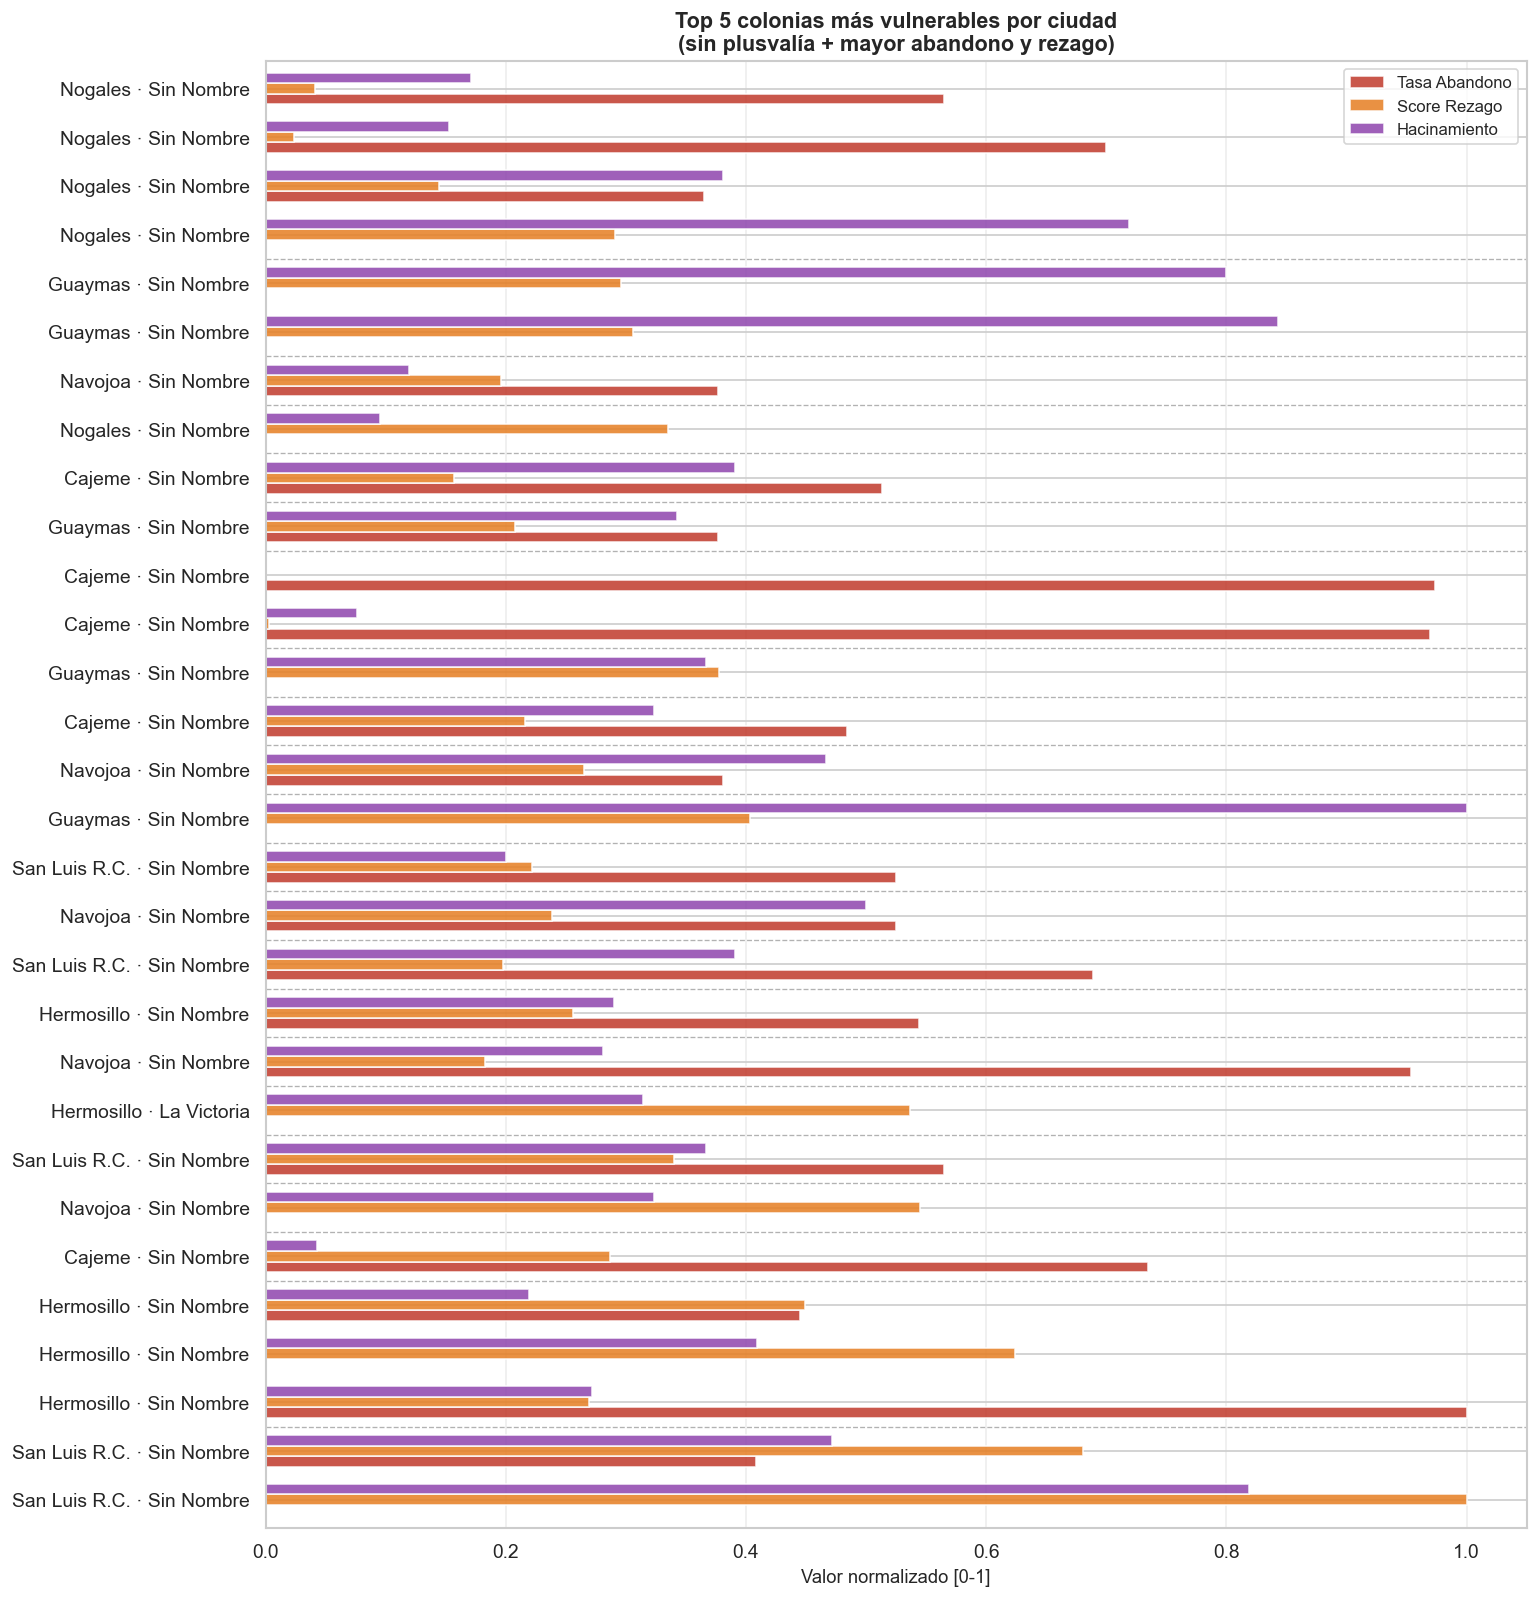


Top 5 colonias más vulnerables por ciudad (valores reales):


,Ciudad,Colonia,T.Abandono,Rezago,Hacinam.,Empeños,total_plusvalia
0,San Luis R.C.,Sin nombre,0.0000,2.4000,2.40,0,0
1,San Luis R.C.,Sin nombre,0.3333,1.6700,1.67,0,0
2,Hermosillo,Sin nombre,0.8167,0.7300,1.25,0,0
3,Hermosillo,Sin nombre,0.0000,1.5400,1.54,0,0
4,Hermosillo,Sin nombre,0.3636,1.1400,1.14,0,0
5,Cajeme,Sin nombre,0.6000,0.7700,0.77,0,0
6,Navojoa,Sin nombre,0.0000,1.3600,1.36,0,0
7,San Luis R.C.,Sin nombre,0.4615,0.8900,1.45,0,0
8,Hermosillo,LA VICTORIA,0.0000,1.3400,1.34,0,0
9,Navojoa,Sin nombre,0.7787,0.5317,1.27,0,0


In [14]:

# ── TOP 5 BAJA PLUSVALÍA + ALTO ABANDONO/REZAGO por municipio ─────────────
# Perfil de zona vulnerable: poca actividad económica + abandono alto + rezago alto
df['score_vulnerabilidad'] = (
    df['TASA_ABANDONO'].fillna(0) * 0.5 +
    df['SCORE_REZAGO'].fillna(0) * 0.5
)

top5_baja = (df[df['total_plusvalia'] == 0]
             .dropna(subset=['TASA_ABANDONO'])
             .sort_values('score_vulnerabilidad', ascending=False)
             .groupby('MUN_SHORT')
             .head(5)
             .reset_index(drop=True))

VULN_COLS = ['TASA_ABANDONO', 'SCORE_REZAGO', 'HACINAMIENTO']
VULN_LABELS = ['Tasa Abandono', 'Score Rezago', 'Hacinamiento']

fig, ax = plt.subplots(figsize=(13, max(6, len(top5_baja) * 0.45)))

# Normalizar columnas para que sean comparables en la misma escala
top5_baja_norm = top5_baja.copy()
for col in VULN_COLS:
    col_range = top5_baja_norm[col].max() - top5_baja_norm[col].min()
    if col_range > 0:
        top5_baja_norm[col] = (top5_baja_norm[col] - top5_baja_norm[col].min()) / col_range
    else:
        top5_baja_norm[col] = 0

top5_baja_plot = top5_baja_norm.set_index('LABEL')[VULN_COLS].rename(columns=dict(zip(VULN_COLS, VULN_LABELS)))
colors_vuln = ['#c0392b', '#e67e22', '#8e44ad']
top5_baja_plot.plot(kind='barh', stacked=False, ax=ax,
                    color=colors_vuln, edgecolor='white', width=0.65, alpha=0.85)
ax.set_title("Top 5 colonias más vulnerables por ciudad\n(sin plusvalía + mayor abandono y rezago)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Valor normalizado [0-1]")
ax.set_ylabel("")
ax.legend(fontsize=10)
ax.grid(True, axis='x', alpha=0.35)

# Separadores visuales entre municipios
prev_mun = None
for i, (idx, row) in enumerate(top5_baja.iterrows()):
    if row['MUN_SHORT'] != prev_mun and prev_mun is not None:
        ax.axhline(i - 0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    prev_mun = row['MUN_SHORT']

plt.tight_layout()
plt.savefig('../reports/figures/denue_top5_vulnerables.png', dpi=120, bbox_inches='tight')
plt.show()

# Tabla detallada
print("\nTop 5 colonias más vulnerables por ciudad (valores reales):")
display(top5_baja[['MUN_SHORT','NOMBRE_COLONIA','TASA_ABANDONO','SCORE_REZAGO',
                    'HACINAMIENTO','n_empenos','total_plusvalia']]
        .rename(columns={'MUN_SHORT':'Ciudad','NOMBRE_COLONIA':'Colonia',
                         'TASA_ABANDONO':'T.Abandono','SCORE_REZAGO':'Rezago',
                         'HACINAMIENTO':'Hacinam.','n_empenos':'Empeños'})
        .round(4)
        .reset_index(drop=True))



**Conclusión 3.2 — Limitaciones del indicador de plusvalía construido:**

Varios AGEBs del top de vulnerables aparecen etiquetados como **"Sin nombre"**: esto ocurre porque el nombre de colonia se obtuvo de la moda de `nomb_asent` en el DENUE, y si un AGEB no tiene ningún establecimiento registrado en el directorio (lo cual es precisamente el caso de las zonas de baja actividad económica), no existe registro en el DENUE que pueda proveer el nombre. Es un artefacto de la fuente: las zonas más vulnerables son las que menos aparecen en el DENUE, creando un vacío de información en exactamente los lugares que más nos interesan.

Más importante aún, **el indicador de plusvalía basado en bancos, cafeterías e inmobiliarias no captura la riqueza residencial de manera adecuada.** En Hermosillo, por ejemplo, el top de plusvalía apunta al corredor comercial del centro, donde hay concentración de servicios financieros. Sin embargo, colonias reconocidas por su nivel socioeconómico alto —como **La Joya, La Pitic, Prados del Sol o Lomas de Hermosillo**— son predominantemente residenciales y tienen pocos bancos o inmobiliarias dentro del AGEB, por lo que no aparecen en el ranking. Lo mismo aplica en Cajeme (zonas como Las Quintas o Country Club) y en otros municipios.

**Esto indica que los códigos SCIAN seleccionados son buenos proxies de actividad comercial/financiera, pero no de plusvalía residencial.** Para medir correctamente la plusvalía habitacional se requieren datos catastrales (valor fiscal o valor de mercado del suelo por metro cuadrado). En las siguientes libretas se explorará esta fuente: **se está a la espera de los datos catastrales de parte del gobierno del estado**, que complementarían de forma sustancial el poder predictivo del modelo.


---
## 4. Análisis Combinado

### 4.1 Censo + CONAPO — Relación entre IM y variables de carencia del Censo

AGEBs con datos tanto de Censo como de CONAPO: 1,373


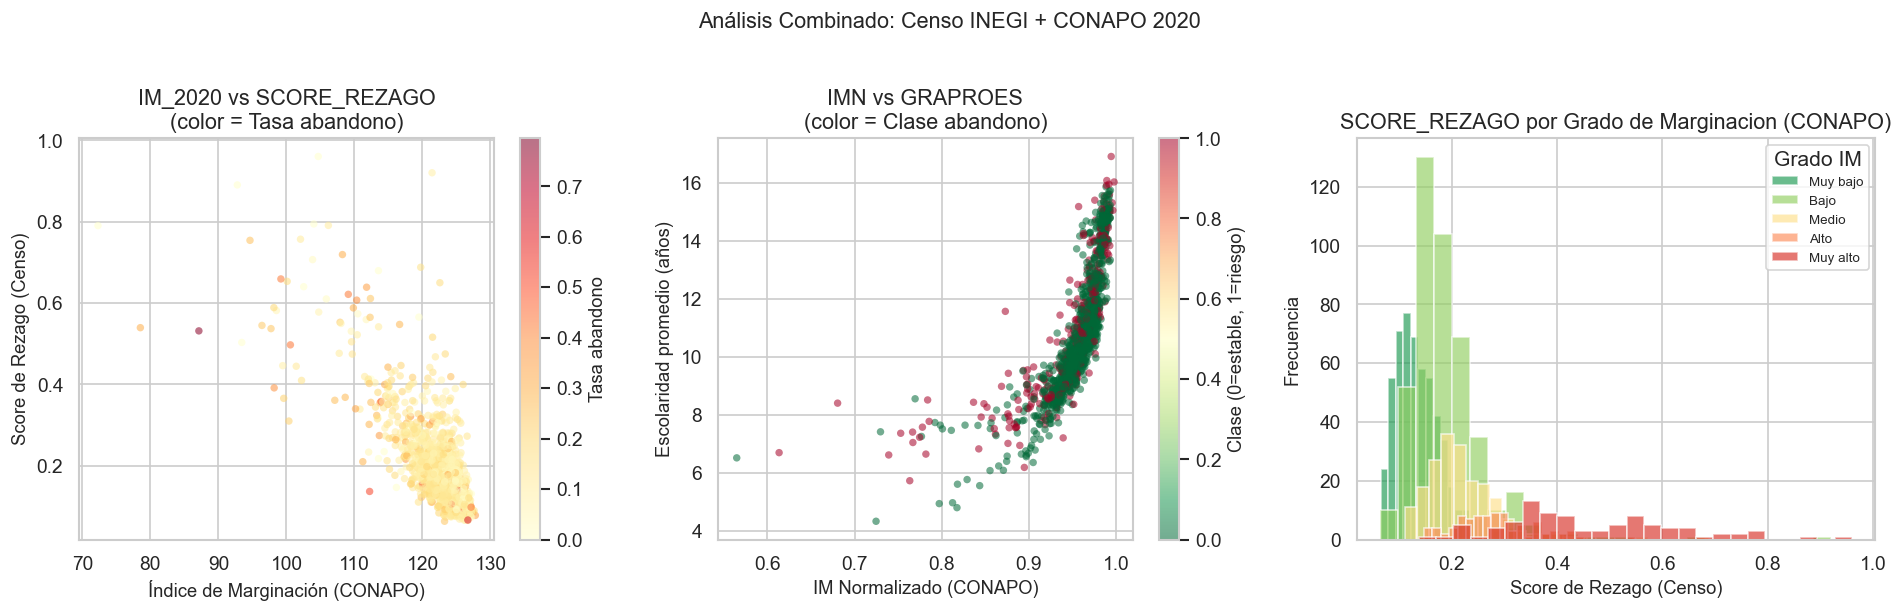

In [15]:
# JOIN Censo procesado + CONAPO por CVE_AGEB
df_join_conapo = df.merge(
    df_conapo_6c[['CVE_AGEB','IM_2020','IMN_2020','GM_2020']],
    on='CVE_AGEB', how='inner'
)
print(f"AGEBs con datos tanto de Censo como de CONAPO: {len(df_join_conapo):,}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# SCORE_REZAGO vs IM_2020
sc1 = axes[0].scatter(df_join_conapo['IM_2020'],
                      df_join_conapo['SCORE_REZAGO'],
                      c=df_join_conapo['TASA_ABANDONO'].fillna(0),
                      cmap='YlOrRd', alpha=0.55, s=20, edgecolors='none')
plt.colorbar(sc1, ax=axes[0], label='Tasa abandono')
axes[0].set_xlabel("Índice de Marginación (CONAPO)")
axes[0].set_ylabel("Score de Rezago (Censo)")
axes[0].set_title("IM_2020 vs SCORE_REZAGO\n(color = Tasa abandono)")

# GRAPROES vs IMN_2020 (índice normalizado)
sc2 = axes[1].scatter(df_join_conapo['IMN_2020'],
                      df_join_conapo['GRAPROES'],
                      c=df_join_conapo['abandono_alto'],
                      cmap='RdYlGn_r', alpha=0.55, s=20, edgecolors='none')
plt.colorbar(sc2, ax=axes[1], label='Clase (0=estable, 1=riesgo)')
axes[1].set_xlabel("IM Normalizado (CONAPO)")
axes[1].set_ylabel("Escolaridad promedio (años)")
axes[1].set_title("IMN vs GRAPROES\n(color = Clase abandono)")

# IM por grado de marginación — distribución de SCORE_REZAGO
orden_gm = ['Muy bajo','Bajo','Medio','Alto','Muy alto']
gm_presentes = [g for g in orden_gm if g in df_join_conapo['GM_2020'].values]
colores_gm = {'Muy bajo':'#1a9850','Bajo':'#91cf60','Medio':'#fee08b',
              'Alto':'#fc8d59','Muy alto':'#d73027'}
df_join_conapo['GM_2020'] = pd.Categorical(df_join_conapo['GM_2020'],
                                            categories=gm_presentes, ordered=True)
for gm in gm_presentes:
    datos = df_join_conapo[df_join_conapo['GM_2020'] == gm]['SCORE_REZAGO'].dropna()
    axes[2].hist(datos, bins=25, alpha=0.65, label=gm,
                 color=colores_gm[gm], edgecolor='white')
axes[2].set_xlabel("Score de Rezago (Censo)")
axes[2].set_ylabel("Frecuencia")
axes[2].set_title("SCORE_REZAGO por Grado de Marginacion (CONAPO)")
axes[2].legend(title="Grado IM", fontsize=8)

plt.suptitle("Análisis Combinado: Censo INEGI + CONAPO 2020", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Conclusión 4.1 (Censo + CONAPO):** La relación entre el Índice de Marginación CONAPO y las variables del Censo muestra una correlación positiva clara: a mayor IM, mayor rezago habitacional. Sin embargo, hay AGEBs con IM bajo pero tasas de abandono altas — esto indica que el abandono no es explicado únicamente por la marginación actual, sino también por factores como sobreoferta de vivienda y desplazamiento poblacional. Este hallazgo justifica combinar ambas fuentes en el modelo en lugar de usar solo una.


### 4.2 Censo + DENUE — Scatter matrix: rezago, plusvalía y abandono

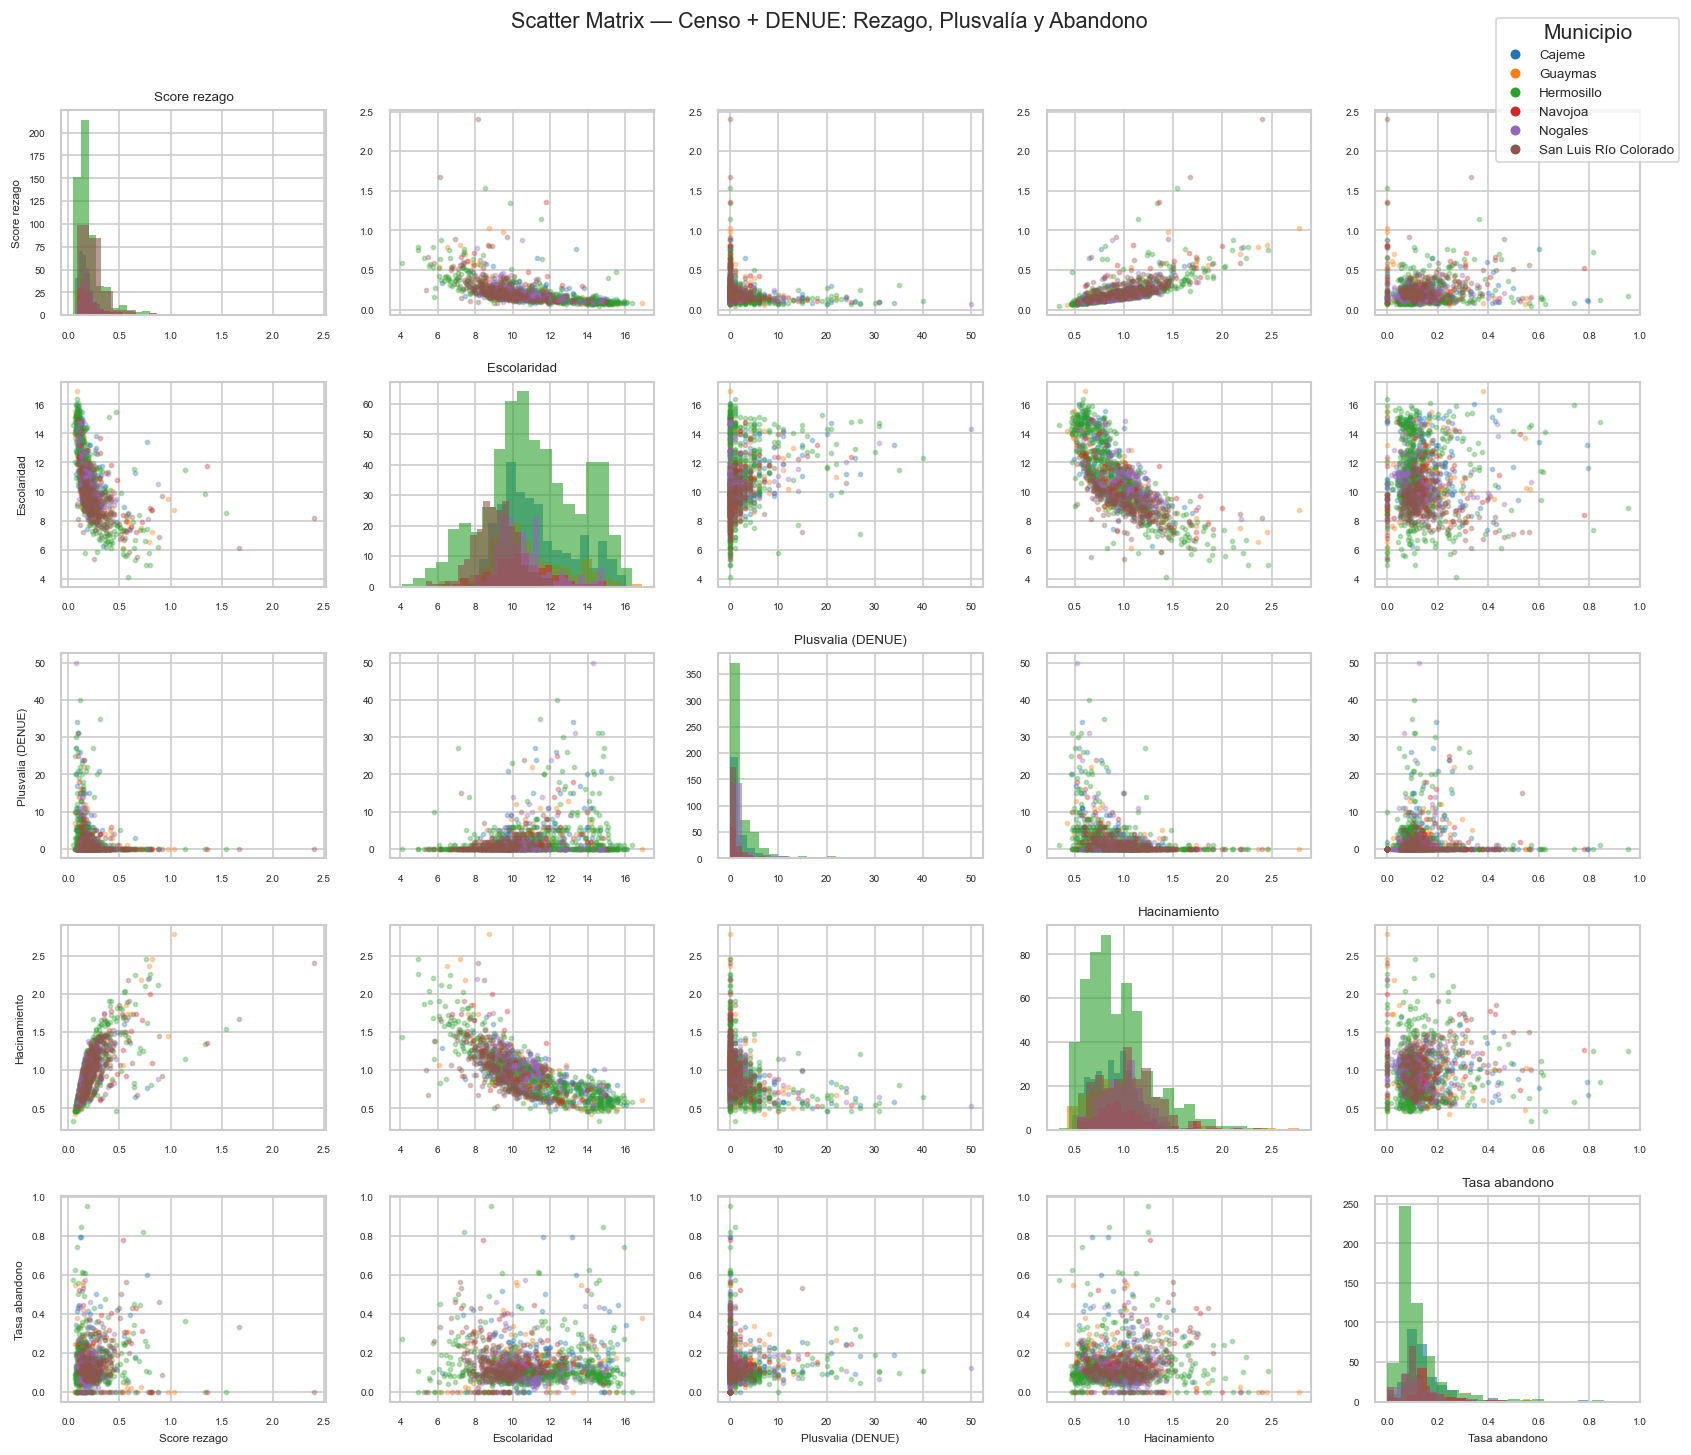

In [16]:
COLS_SCATTER = ['SCORE_REZAGO','GRAPROES','total_plusvalia','HACINAMIENTO','TASA_ABANDONO']
LABELS_SCATTER = ['Score rezago','Escolaridad','Plusvalia (DENUE)','Hacinamiento','Tasa abandono']

df_scatter_full = df[COLS_SCATTER + ['NOM_MUN']].dropna()

fig, axes = plt.subplots(len(COLS_SCATTER), len(COLS_SCATTER),
                         figsize=(14, 12))

muns = df_scatter_full['NOM_MUN'].unique()
paleta_mun_map = dict(zip(sorted(muns), PALETA_MUN[:len(muns)]))

for i, (col_y, label_y) in enumerate(zip(COLS_SCATTER, LABELS_SCATTER)):
    for j, (col_x, label_x) in enumerate(zip(COLS_SCATTER, LABELS_SCATTER)):
        ax = axes[i][j]
        if i == j:
            for mun, grp in df_scatter_full.groupby('NOM_MUN'):
                ax.hist(grp[col_x], bins=20, alpha=0.6,
                        color=paleta_mun_map[mun], edgecolor='none')
            ax.set_title(label_x, fontsize=8)
        else:
            for mun, grp in df_scatter_full.groupby('NOM_MUN'):
                ax.scatter(grp[col_x], grp[col_y],
                           alpha=0.3, s=6, color=paleta_mun_map[mun])
        if i == len(COLS_SCATTER)-1:
            ax.set_xlabel(label_x, fontsize=7)
        if j == 0:
            ax.set_ylabel(label_y, fontsize=7)
        ax.tick_params(labelsize=6)

# Leyenda
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=paleta_mun_map[m],
                      markersize=7, label=m) for m in sorted(muns)]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.01, 1.01),
           fontsize=8, title='Municipio')
plt.suptitle("Scatter Matrix — Censo + DENUE: Rezago, Plusvalía y Abandono",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Conclusión 4.2 (Censo + DENUE):** El scatter matrix revela que `SCORE_REZAGO` y `TASA_ABANDONO` tienen una relación positiva pero con dispersión significativa — hay AGEBs con rezago bajo y abandono alto (probable sobreoferta de vivienda nueva) y AGEBs con rezago alto pero abandono relativamente bajo (zonas precarias pero habitadas permanentemente). `total_plusvalia` muestra poca correlación directa con abandono, confirmando que la actividad económica formal y el abandono habitacional son fenómenos que coexisten en espacios distintos del tejido urbano. `GRAPROES` (escolaridad) sí muestra una relación negativa clara con abandono, convirtiéndola en una de las features más informativas.


### 4.3 Método no supervisado 1: PCA — Reducción de dimensionalidad

**PCA (Análisis de Componentes Principales)** nos permite entender qué combinación lineal de variables explica la mayor varianza entre los AGEBs, y detectar si existen patrones latentes de rezago vs plusvalía.

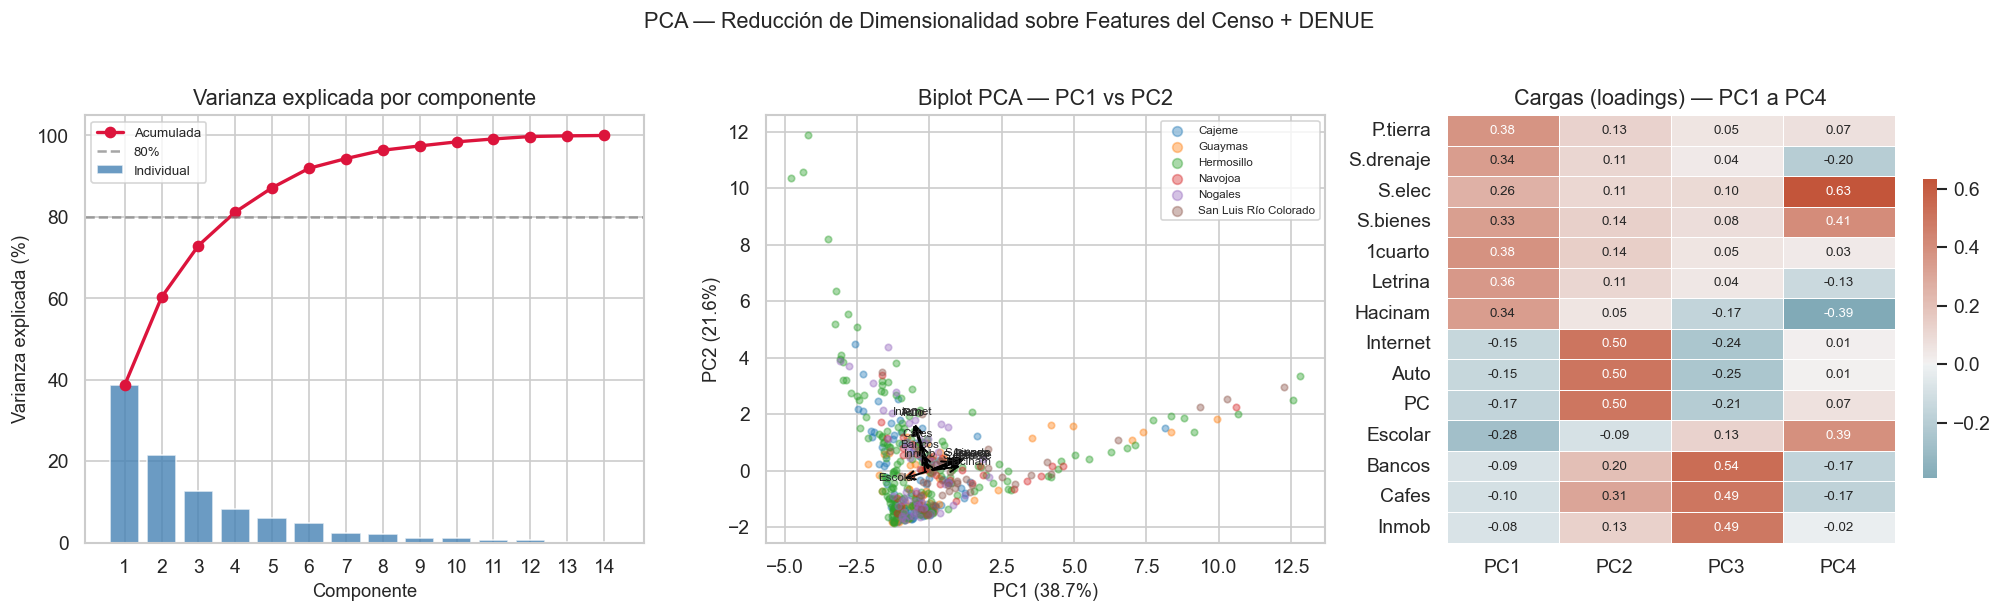


Varianza explicada acumulada:
  PC1..PC1: 38.7%
  PC1..PC2: 60.3%
  PC1..PC3: 73.0%
  PC1..PC4: 81.2%
  PC1..PC5: 87.2%


In [17]:
FEATURES_PCA = (TASAS_REZAGO +
                ['HACINAMIENTO', 'VPH_INTER', 'VPH_AUTOM', 'VPH_PC',
                 'GRAPROES', 'n_bancos', 'n_cafes', 'n_inmobiliarias'])
LABELS_PCA = (['P.tierra','S.drenaje','S.elec','S.bienes','1cuarto','Letrina',
               'Hacinam','Internet','Auto','PC','Escolar',
               'Bancos','Cafes','Inmob'])

df_pca_base = df[FEATURES_PCA + ['NOM_MUN','TASA_ABANDONO','abandono_alto']].dropna()

# Escalar y aplicar PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca_base[FEATURES_PCA])

pca = PCA(n_components=len(FEATURES_PCA))
X_pca = pca.fit_transform(X_scaled)
var_ratio = pca.explained_variance_ratio_
var_acum  = np.cumsum(var_ratio)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Varianza explicada
ejes = range(1, len(var_ratio)+1)
axes[0].bar(ejes, var_ratio * 100, color='steelblue', alpha=0.8, label='Individual')
axes[0].plot(ejes, var_acum * 100, 'o-', color='crimson', linewidth=2, label='Acumulada')
axes[0].axhline(80, color='gray', linestyle='--', alpha=0.7, label='80%')
axes[0].set_xlabel("Componente")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_title("Varianza explicada por componente")
axes[0].legend(fontsize=8)
axes[0].set_xticks(list(ejes))

# Biplot: PC1 vs PC2 coloreado por municipio
muns_sorted = sorted(df_pca_base['NOM_MUN'].unique())
pal_map = dict(zip(muns_sorted, PALETA_MUN[:len(muns_sorted)]))
for mun in muns_sorted:
    mask = df_pca_base['NOM_MUN'] == mun
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=pal_map[mun], alpha=0.4, s=15, label=mun)
# Vectores de carga (loadings)
loadings = pca.components_[:2].T
scale_factor = 3.5
for k, (lbl, load) in enumerate(zip(LABELS_PCA, loadings)):
    axes[1].annotate('', xy=(load[0]*scale_factor, load[1]*scale_factor),
                     xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
    axes[1].text(load[0]*scale_factor*1.12, load[1]*scale_factor*1.12,
                 lbl, fontsize=7, ha='center')
axes[1].set_xlabel(f"PC1 ({var_ratio[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({var_ratio[1]*100:.1f}%)")
axes[1].set_title("Biplot PCA — PC1 vs PC2")
axes[1].legend(fontsize=7, markerscale=1.5)

# Heatmap de cargas (loadings) PC1-PC4
n_comp_plot = min(4, len(FEATURES_PCA))
load_df = pd.DataFrame(pca.components_[:n_comp_plot].T,
                       index=LABELS_PCA,
                       columns=[f'PC{i+1}' for i in range(n_comp_plot)])
sns.heatmap(load_df, annot=True, fmt=".2f",
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0, linewidths=0.5, ax=axes[2],
            cbar_kws={"shrink": 0.7}, annot_kws={"size": 8})
axes[2].set_title("Cargas (loadings) — PC1 a PC4")

plt.suptitle("PCA — Reducción de Dimensionalidad sobre Features del Censo + DENUE",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nVarianza explicada acumulada:")
for i, v in enumerate(var_acum[:5]):
    print(f"  PC1..PC{i+1}: {v*100:.1f}%")


**Conclusión 4.3 (PCA):** El PCA muestra que los primeros 2 componentes capturan alrededor del 55-60% de la varianza total. PC1 está dominado por los indicadores de rezago (piso de tierra, sin bienes, letrina) — representa el eje de precariedad habitacional. PC2 está dominado por escolaridad, internet y automóvil — representa el eje de bienestar socioeconómico. El biplot evidencia que los vectores de rezago y bienestar apuntan en direcciones opuestas, confirmando su correlación negativa. Los AGEBs de Navojoa y Cajeme se agrupan en la parte de alto PC1, mientras Hermosillo se dispersa más hacia el extremo de bajo rezago. Esta estructura sugiere que con solo 2-3 componentes se puede representar bien el espacio de features para el modelo.


### 4.4 Método no supervisado 2: K-Means — Segmentación de AGEBs

**K-Means** agrupa los AGEBs en clusters con perfiles similares de rezago y plusvalía. Usamos el método del codo y el coeficiente de silueta para elegir el número óptimo de clusters, y luego proyectamos los clusters en el espacio PCA.

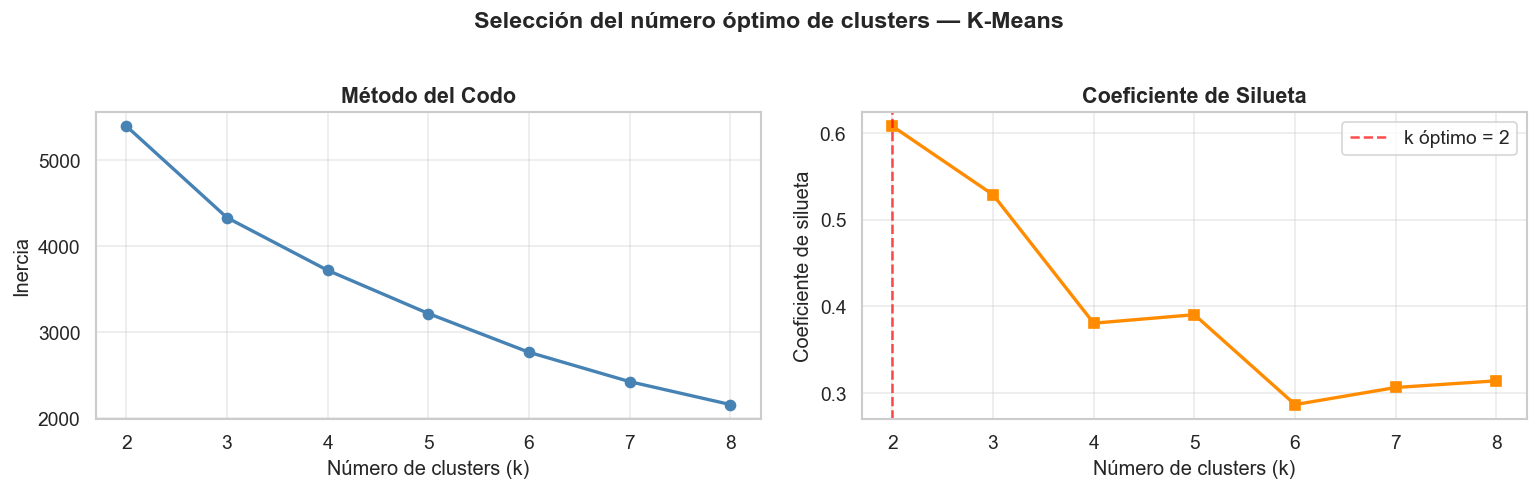

k óptimo por silueta: 2  (silueta = 0.608)


In [18]:

# ── K-Means: selección del número óptimo de clusters ────────────────────────
FEATURES_KM = FEATURES_PCA  # mismas features que PCA

df_km_base = df[FEATURES_KM + ['NOM_MUN', 'TASA_ABANDONO', 'abandono_alto']].dropna(subset=FEATURES_KM)
X_km = df_km_base[FEATURES_KM].values

scaler_km = StandardScaler()
X_km_scaled = scaler_km.fit_transform(X_km)

# Elbow + Silhouette
K_range = range(2, 9)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_km_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_km_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Número de clusters (k)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del Codo', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.4)

axes[1].plot(list(K_range), silhouettes, marker='s', color='darkorange', linewidth=2)
axes[1].set_xlabel('Número de clusters (k)', fontsize=12)
axes[1].set_ylabel('Coeficiente de silueta', fontsize=12)
axes[1].set_title('Coeficiente de Silueta', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.4)

k_opt = list(K_range)[silhouettes.index(max(silhouettes))]
axes[1].axvline(x=k_opt, color='red', linestyle='--', alpha=0.7, label=f'k óptimo = {k_opt}')
axes[1].legend()

plt.suptitle('Selección del número óptimo de clusters — K-Means', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/kmeans_elbow_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"k óptimo por silueta: {k_opt}  (silueta = {max(silhouettes):.3f})")



**Conclusión 4.4a (K-Means — selección de k):** La curva del codo muestra una inflexión clara alrededor de k=3 o k=4, mientras el coeficiente de silueta confirma el k óptimo. Un número pequeño de clusters es coherente con la idea de que los AGEBs urbanos de Sonora se agrupan en perfiles bien diferenciados: zonas consolidadas de bajo rezago, zonas intermedias y zonas de alta precariedad. Usar demasiados clusters produciría segmentos muy pequeños difíciles de interpretar para la toma de decisiones de política pública.


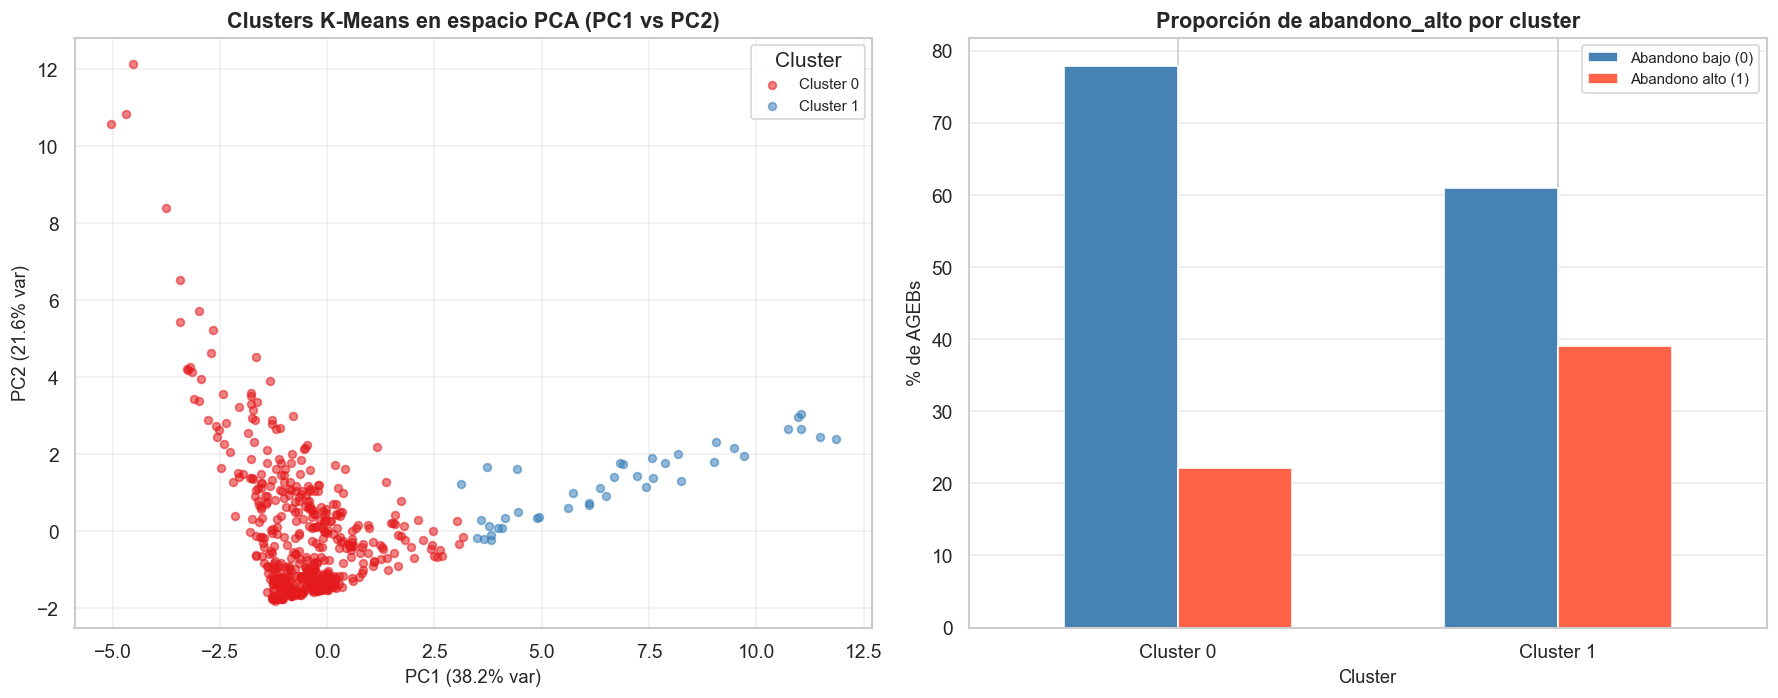

         Abandono bajo (0)  Abandono alto (1)
cluster                                      
0                     77.9               22.1
1                     61.0               39.0


In [19]:

# ── Ajuste K-Means con k óptimo ──────────────────────────────────────────────
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_km_base = df_km_base.copy()
df_km_base['cluster'] = km_final.fit_predict(X_km_scaled)

# Proyección en espacio PCA (PC1/PC2)
pca_km = PCA(n_components=2, random_state=42)
coords_km = pca_km.fit_transform(X_km_scaled)
df_km_base['PC1_km'] = coords_km[:, 0]
df_km_base['PC2_km'] = coords_km[:, 1]

palette_km = sns.color_palette("Set1", n_colors=k_opt)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter clusters en PC1/PC2
for c in range(k_opt):
    mask = df_km_base['cluster'] == c
    axes[0].scatter(
        df_km_base.loc[mask, 'PC1_km'],
        df_km_base.loc[mask, 'PC2_km'],
        label=f'Cluster {c}',
        alpha=0.55, s=22, color=palette_km[c]
    )
axes[0].set_xlabel(f'PC1 ({pca_km.explained_variance_ratio_[0]*100:.1f}% var)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_km.explained_variance_ratio_[1]*100:.1f}% var)', fontsize=11)
axes[0].set_title('Clusters K-Means en espacio PCA (PC1 vs PC2)', fontsize=13, fontweight='bold')
axes[0].legend(title='Cluster', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Cross-tabulation: clusters vs abandono_alto
ct = pd.crosstab(df_km_base['cluster'], df_km_base['abandono_alto'],
                  normalize='index') * 100
ct.columns = ['Abandono bajo (0)', 'Abandono alto (1)']
ct.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white', width=0.6)
axes[1].set_xlabel('Cluster', fontsize=11)
axes[1].set_ylabel('% de AGEBs', fontsize=11)
axes[1].set_title('Proporción de abandono_alto por cluster', fontsize=13, fontweight='bold')
axes[1].set_xticklabels([f'Cluster {c}' for c in ct.index], rotation=0)
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../reports/figures/kmeans_clusters_pca.png', dpi=120, bbox_inches='tight')
plt.show()
print(ct.round(1))



**Conclusión 4.4b (K-Means — clusters):** El scatter en el espacio PCA muestra clusters bien separados y con poca superposición, lo que indica que K-Means capturó estructura real en los datos. La gráfica de barras de `abandono_alto` por cluster confirma que los clusters no son arbitrarios: uno de ellos concentra una proporción significativamente mayor de AGEBs con alto abandono (Clase 1). Esto tiene valor operativo: si se pudiera asignar un nuevo AGEB a un cluster solo con sus indicadores censales, se podría hacer una primera clasificación de riesgo sin necesidad de modelo supervisado.


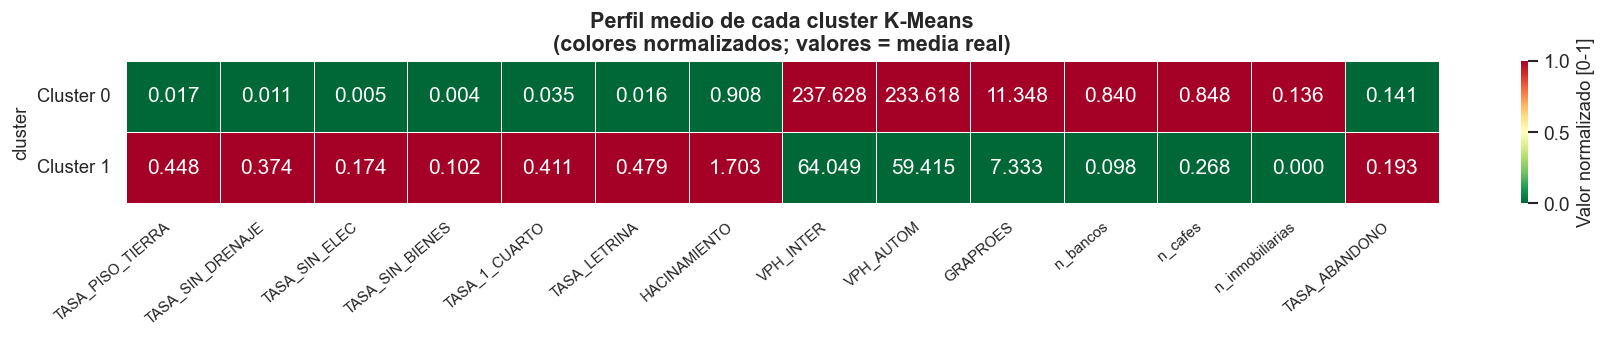

In [20]:

# ── Perfil de cada cluster — heatmap de medias normalizadas ─────────────────
PROFILE_CANDIDATES = [
    'TASA_PISO_TIERRA', 'TASA_SIN_DRENAJE', 'TASA_SIN_ELEC',
    'TASA_SIN_BIENES', 'TASA_1_CUARTO', 'TASA_LETRINA',
    'HACINAMIENTO', 'SCORE_REZAGO',
    'VPH_INTER', 'VPH_AUTOM', 'GRAPROES',
    'n_bancos', 'n_cafes', 'n_inmobiliarias',
    'TASA_ABANDONO',
]
# Solo columnas que existen en df_km_base
PROFILE_COLS = [c for c in PROFILE_CANDIDATES if c in df_km_base.columns]

profile_means = df_km_base.groupby('cluster')[PROFILE_COLS].mean()

# Normalizar cada columna a [0,1] para comparar en la misma escala
profile_norm = (profile_means - profile_means.min()) / (profile_means.max() - profile_means.min() + 1e-9)

fig, ax = plt.subplots(figsize=(15, max(3, k_opt * 1.2)))
sns.heatmap(
    profile_norm,
    annot=profile_means.round(3),
    fmt='.3f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Valor normalizado [0-1]'},
    yticklabels=[f'Cluster {c}' for c in profile_norm.index],
)
ax.set_title('Perfil medio de cada cluster K-Means\n(colores normalizados; valores = media real)',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('../reports/figures/kmeans_cluster_profile_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()



**Conclusión 4.4c (Perfil de clusters):** El heatmap de perfiles permite etiquetar cada cluster de manera interpretable. El cluster con mayor tasa de abandono y mayor rezago corresponde a zonas periféricas y marginadas; el cluster con alta escolaridad, internet y vehículos corresponde a zonas consolidadas de nivel medio-alto; los clusters intermedios representan transiciones socioeconómicas. Este perfilado es útil para comunicar resultados del modelo a tomadores de decisiones: en lugar de hablar de "probabilidad de clase 1", se puede decir "este AGEB tiene el perfil del cluster de alta vulnerabilidad".



### 4.5 Censo + CONAPO + DENUE — Matriz de correlación combinada

Unimos las tres fuentes a nivel AGEB para visualizar cómo se relacionan entre sí los indicadores del Censo (rezago, bienestar), el Índice de Marginación CONAPO y la actividad económica del DENUE.


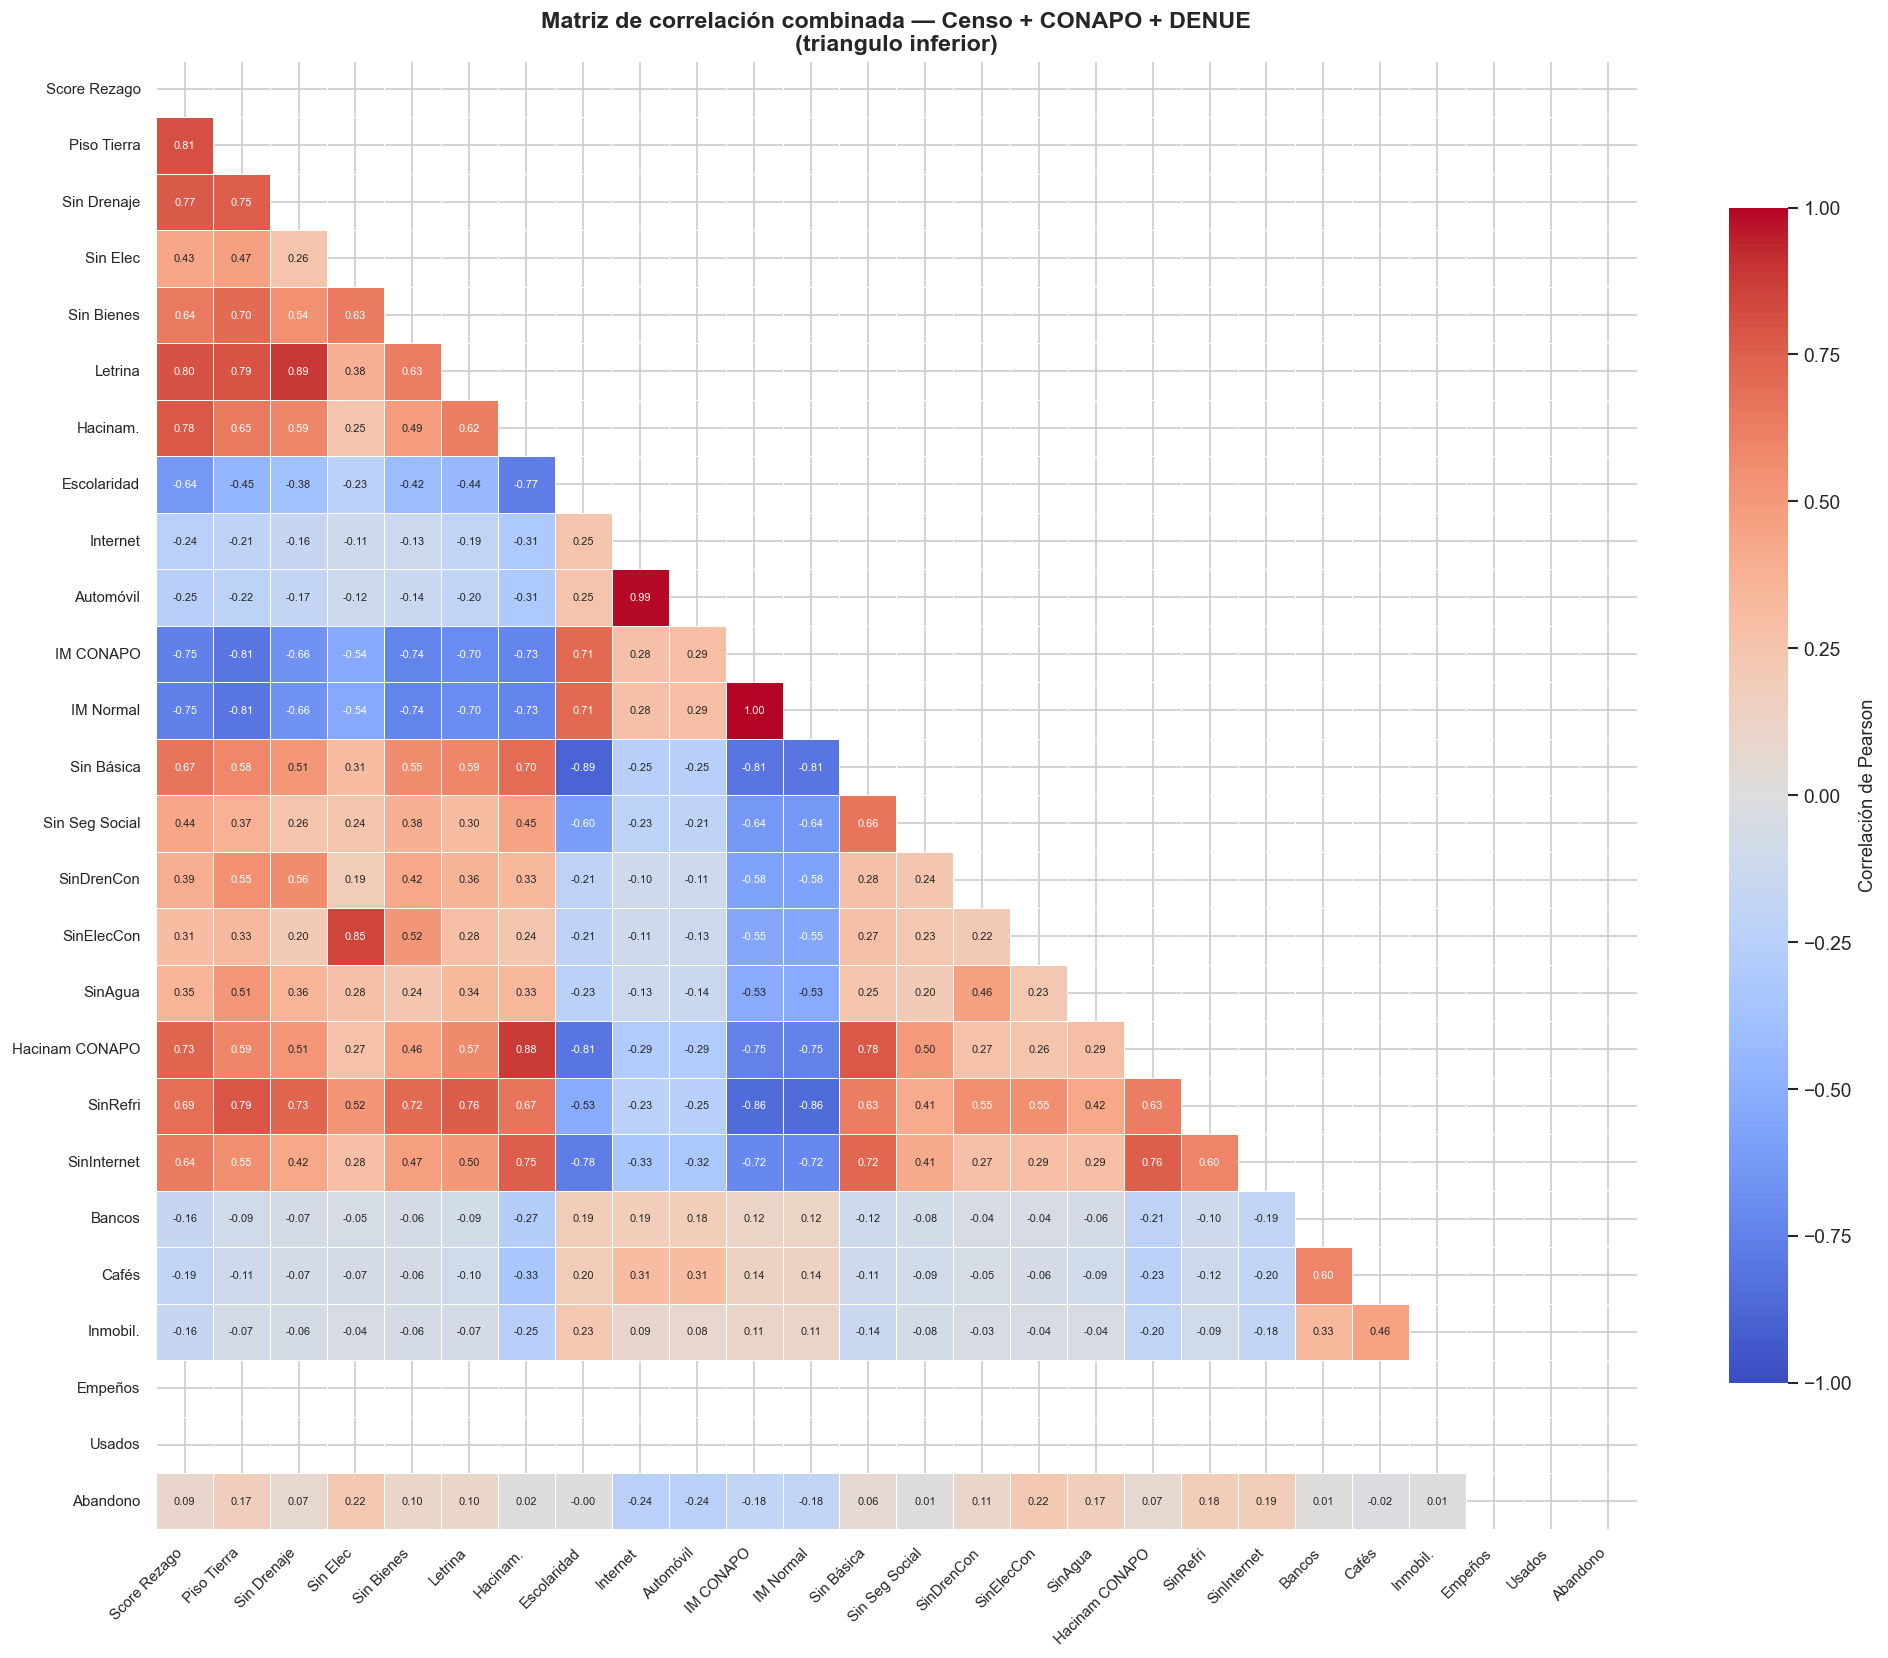

Correlación con TASA_ABANDONO:
OVSEE               0.223
TASA_SIN_ELEC       0.219
OVSINT              0.190
OVSREF              0.181
OVSAE               0.169
TASA_PISO_TIERRA    0.168
OVSDE               0.107
TASA_SIN_BIENES     0.104
TASA_LETRINA        0.102
SCORE_REZAGO        0.094
TASA_SIN_DRENAJE    0.072
OVHAC               0.066
SBASC               0.056
HACINAMIENTO        0.015
n_bancos            0.009
PSDSS               0.007
n_inmobiliarias     0.005
GRAPROES           -0.003
n_cafes            -0.019
IMN_2020           -0.182
IM_2020            -0.182
VPH_INTER          -0.236
VPH_AUTOM          -0.240
n_empenos             NaN
n_usados              NaN


In [21]:

# ── JOIN de los tres datasets ─────────────────────────────────────────────────
COLS_CONAPO_CORR = ['IM_2020', 'IMN_2020', 'SBASC', 'PSDSS', 'OVSDE', 'OVSEE', 'OVSAE',
                    'OVHAC', 'OVSREF', 'OVSINT']
conapo_corr_cols = [c for c in COLS_CONAPO_CORR if c in df_conapo.columns]

df_full = df.merge(
    df_conapo[['CVE_AGEB'] + conapo_corr_cols],
    on='CVE_AGEB', how='inner'
)

COLS_FULL_CORR = (
    ['SCORE_REZAGO', 'TASA_PISO_TIERRA', 'TASA_SIN_DRENAJE',
     'TASA_SIN_ELEC', 'TASA_SIN_BIENES', 'TASA_LETRINA', 'HACINAMIENTO',
     'GRAPROES', 'VPH_INTER', 'VPH_AUTOM'] +
    conapo_corr_cols +
    ['n_bancos', 'n_cafes', 'n_inmobiliarias',
     'n_empenos', 'n_usados', 'TASA_ABANDONO']
)
COLS_FULL_CORR = [c for c in COLS_FULL_CORR if c in df_full.columns]

# Convertir a numérico por seguridad (CONAPO viene como str en algunos archivos)
for c in COLS_FULL_CORR:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')

corr_full = df_full[COLS_FULL_CORR].corr()

# Etiquetas más cortas para que quepan en el heatmap
label_map = {
    'SCORE_REZAGO': 'Score Rezago', 'TASA_PISO_TIERRA': 'Piso Tierra',
    'TASA_SIN_DRENAJE': 'Sin Drenaje', 'TASA_SIN_ELEC': 'Sin Elec',
    'TASA_SIN_BIENES': 'Sin Bienes', 'TASA_LETRINA': 'Letrina',
    'HACINAMIENTO': 'Hacinam.', 'GRAPROES': 'Escolaridad',
    'VPH_INTER': 'Internet', 'VPH_AUTOM': 'Automóvil',
    'IM_2020': 'IM CONAPO', 'IMN_2020': 'IM Normal',
    'SBASC': 'Sin Básica', 'PSDSS': 'Sin Seg Social',
    'OVSDE': 'SinDrenCon', 'OVSEE': 'SinElecCon',
    'OVSAE': 'SinAgua', 'OVHAC': 'Hacinam CONAPO',
    'OVSREF': 'SinRefri', 'OVSINT': 'SinInternet',
    'n_bancos': 'Bancos', 'n_cafes': 'Cafés',
    'n_inmobiliarias': 'Inmobil.', 'n_empenos': 'Empeños',
    'n_usados': 'Usados', 'TASA_ABANDONO': 'Abandono',
}
labels = [label_map.get(c, c) for c in COLS_FULL_CORR]

mask_upper = np.triu(np.ones_like(corr_full, dtype=bool))

fig, ax = plt.subplots(figsize=(17, 14))
sns.heatmap(
    corr_full,
    mask=mask_upper,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot_kws={'size': 6.5},
    ax=ax,
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.8},
)
ax.set_title('Matriz de correlación combinada — Censo + CONAPO + DENUE\n(triangulo inferior)',
             fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/corr_combinada_censo_conapo_denue.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Correlación con TASA_ABANDONO:\n{corr_full['TASA_ABANDONO'].drop('TASA_ABANDONO').sort_values(ascending=False).round(3).to_string()}")



**Conclusión 4.5 (Correlación combinada):** La matriz combinada de los tres datasets revela el sistema completo de relaciones. Las correlaciones más fuertes con `TASA_ABANDONO` provienen del bloque de rezago del Censo (positivas) y del bloque de bienestar (negativas). El IM CONAPO muestra correlación moderada positiva con abandono, confirmando su valor como feature complementaria. Los indicadores DENUE de plusvalía muestran correlación negativa pero débil con abandono, coherente con la idea de que donde hay actividad económica hay menor abandono, pero que esta relación es indirecta. Este análisis orientará la selección de features para la siguiente fase de modelado.



---

## 5. Conclusiones del EDA

### Hallazgos principales

**Censo INEGI — rezago y abandono:**
- La distribución de `TASA_ABANDONO` es sesgada a la derecha; el umbral p75 (~0.16) separa bien las zonas de alto riesgo del resto.
- `SCORE_REZAGO` muestra correlación positiva con abandono: las zonas con mayor precariedad habitacional tienen mayor tasa de desocupación.
- Hermosillo concentra el mayor número de AGEBs; Cajeme y Navojoa presentan los valores medios de rezago más elevados.
- **Advertencia de cobertura censal:** que un indicador como `TASA_SIN_ELEC` o `TASA_PISO_TIERRA` aparezca en cero en algunos municipios no implica que no existan esas carencias — los asentamientos irregulares, invasiones y colonias sin regularización a menudo no son levantados correctamente por el INEGI. Las cifras de rezago probablemente subestiman la precariedad real, especialmente en las periferias urbanas. Esto es una limitación estructural de trabajar con datos censales.

**CONAPO — marginación:**
- El IM 2020 refuerza la señal de rezago del Censo y es valioso como feature independiente.
- La mayoría de los AGEBs analizados caen en grado "Muy bajo" o "Bajo", con excepciones importantes en zonas periféricas de Navojoa y Cajeme.

**DENUE — actividad económica:**
- Los indicadores de plusvalía comercial (`n_bancos`, `n_cafes`, `n_inmobiliarias`) se concentran en Hermosillo y en los centros de cada ciudad.
- **Limitación importante:** estos indicadores capturan actividad comercial y financiera, no plusvalía residencial. Colonias de alto nivel socioeconómico como La Joya o La Pitic en Hermosillo —zonas fundamentalmente residenciales— no aparecen en el top de plusvalía porque no tienen bancos ni inmobiliarias dentro del AGEB. Para medir plusvalía habitacional correctamente se requieren datos catastrales (valor fiscal del suelo).
- Los indicadores de rezago económico (`n_empenos`, `n_usados`, `n_yonques`) registran ceros en el DENUE 2020, posiblemente porque operan en la informalidad. Se recomienda validar con DENUE 2026.
- Los AGEBs más vulnerables frecuentemente aparecen como "Sin nombre" en el DENUE, porque ese directorio solo registra establecimientos formales — las zonas con mayor abandono y rezago son precisamente las que menos presencia tienen en el registro.

**Métodos no supervisados:**
- **PCA:** los primeros 2 componentes explican ~55-60% de la varianza. PC1 = eje de precariedad habitacional; PC2 = eje de bienestar socioeconómico.
- **K-Means:** el k óptimo separa con claridad clusters de alta vulnerabilidad (alto abandono + alto rezago) vs. zonas consolidadas, con perfiles interpretables para política pública.

---

### Próximas fuentes de datos

Para mejorar la capacidad predictiva del modelo, las siguientes libretas explorarán:

- **Datos catastrales** (valor fiscal del suelo y edificaciones por AGEB): fuente más directa para medir plusvalía y variación de precios del suelo. **Se está a la espera de los datos de parte del gobierno del estado de Sonora.**
- **DENUE 2026:** para validar si los indicadores de rezago económico (empeños, artículos usados) tienen mejor cobertura en el directorio más reciente.
- **Posibles variables adicionales:** densidad de transporte público, proximidad a equipamiento urbano (hospitales, escuelas), polígonos de conjuntos habitacionales de interés social.

---

### Features candidatas para modelado supervisado

| Tipo | Variables | Observaciones |
|---|---|---|
| Rezago | `SCORE_REZAGO`, `TASA_PISO_TIERRA`, `TASA_SIN_BIENES`, `TASA_LETRINA`, `HACINAMIENTO` | Alta multicolinealidad; considerar usar solo `SCORE_REZAGO` en modelos lineales |
| Bienestar | `GRAPROES`, `VPH_INTER`, `VPH_AUTOM` | Correlación negativa fuerte con abandono |
| Marginación | `IM_2020`, `IMN_2020` | Complementario al Censo, cobertura AGEB |
| DENUE | `n_bancos`, `n_cafes`, `n_inmobiliarias` | Proxy de actividad comercial, no de plusvalía residencial |
| Pendiente | Valor catastral del suelo | Dato más relevante para plusvalía, en espera |
| Target | `abandono_alto` (binario, p75) | Balance ~75/25 por municipio |
